# PTSD Veterans Data Analysis

In [ ]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

## Setup and Data Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Mount Google Drive

### List Data Files

In [ ]:
import os

data_path = '/content/drive/MyDrive/Colab Notebooks/Data set/'

if os.path.exists(data_path):
    print(f"Contents of '{data_path}':")
    for item in os.listdir(data_path):
        print(f"- {item}")
else:
    print(f"Error: The path '{data_path}' does not exist. Please verify the folder structure in your Google Drive and update 'data_path'.")

Contents of '/content/drive/MyDrive/Colab Notebooks/Data set/':
- Abbreviations_20250403.csv
- PTSD_Continuous_Outcomes_Between_Arms_20250403.csv
- PTSD_Dichotomous_Outcomes_Between_Arms_20250403.csv
- PTSD_Dichotomous_Outcomes_Within_Arms_20250403.csv
- Harms_20250403.csv
- Other_Outcomes_20250403.csv
- PTSD_Continuous_Outcomes_Within_Arms_20250403.csv
- References_and_Study_Identifiers_20250403.csv
- Secondary_Studies_20250403.csv
- Sample_Characteristics_20250403.csv
- Study_Interventions_20250403.csv
- Suicide_and_Self-harm_Continuous_Outcomes_-_Between_Arms_20250403.csv
- Suicide_and_Self-harm_Continuous_Outcomes_-_Within_Arms_20250403.csv
- Risk_Of_Bias_20250403.csv
- Study_Characteristics_20250403.csv
- Suicide_and_Self-harm_Dichotomous_Outcomes_-_Within_Arms_20250403.csv
- Suicide_and_Self-harm_Dichotomous_Outcomes_-_Between_Arms_20250403.csv
- Final_Veterans_PTSD_Dataset.csv
- Final_Veterans_PTSD_Dataset_2.csv


### Load CSV Files into DataFrames

In [ ]:
csv_files = [f for f in os.listdir(data_path) if f.endswith('.csv')]

dataframes = {}

for filename in csv_files:
    file_path = os.path.join(data_path, filename)
    df_name = os.path.splitext(filename)[0] # Get filename without extension
    try:
        dataframes[df_name] = pd.read_csv(file_path)
        print(f"Successfully loaded '{filename}' as '{df_name}'")
    except Exception as e:
        print(f"Error loading '{filename}': {e}")

# Display the head of one of the loaded dataframes as an example
if 'Study_Interventions_20250403' in dataframes:
    print("\nDisplaying the first 5 rows of 'Study_Interventions_20250403':")
    display(dataframes['Study_Interventions_20250403'].head())
elif dataframes:
    # If 'Study_Interventions_20250403' is not there, pick the first one available
    first_df_name = next(iter(dataframes))
    print(f"\nDisplaying the first 5 rows of '{first_df_name}':")
    display(dataframes[first_df_name].head())
else:
    print("No CSV files were loaded.")

Error loading 'Abbreviations_20250403.csv': name 'pd' is not defined
Error loading 'PTSD_Continuous_Outcomes_Between_Arms_20250403.csv': name 'pd' is not defined
Error loading 'PTSD_Dichotomous_Outcomes_Between_Arms_20250403.csv': name 'pd' is not defined
Error loading 'PTSD_Dichotomous_Outcomes_Within_Arms_20250403.csv': name 'pd' is not defined
Error loading 'Harms_20250403.csv': name 'pd' is not defined
Error loading 'Other_Outcomes_20250403.csv': name 'pd' is not defined
Error loading 'PTSD_Continuous_Outcomes_Within_Arms_20250403.csv': name 'pd' is not defined
Error loading 'References_and_Study_Identifiers_20250403.csv': name 'pd' is not defined
Error loading 'Secondary_Studies_20250403.csv': name 'pd' is not defined
Error loading 'Sample_Characteristics_20250403.csv': name 'pd' is not defined
Error loading 'Study_Interventions_20250403.csv': name 'pd' is not defined
Error loading 'Suicide_and_Self-harm_Continuous_Outcomes_-_Between_Arms_20250403.csv': name 'pd' is not defined
Er

### Inspect DataFrame Columns

In [ ]:
print("Binary:\n", dataframes['PTSD_Dichotomous_Outcomes_Between_Arms_20250403'].columns)
print("\nInterventions:\n", dataframes['Study_Interventions_20250403'].columns)
print("\nBaseline:\n", dataframes['Sample_Characteristics_20250403'].columns)

Binary:
 Index(['Study ID', 'PTSDpubs ID', 'Analysis Type',
       'Adjusted Variables in Statistical Analysis',
       'Method for Handling Missing Data', 'Statistical Analysis Method',
       'Comparison Arms Designation', 'Assessment Point',
       'Diagnostic Change Definition Number', 'Diagnostic Change Definition',
       'Diagnostic Change 1 Effect Size Detail',
       'Diagnostic Change 1 Effect Size Type',
       'Diagnostic Change 1 Effect Size',
       'Diagnostic Change 1 Effect Size Type of Variance Measure',
       'Diagnostic Change 1 Effect Size Variance Value or Lower Bound',
       'Diagnostic Change 1 Effect Size Variance Upper Bound',
       'Diagnostic Change 1 Effect Size p value',
       'Clinically Meaningful Response Definition Number',
       'Clinically Meaningful Response Definition',
       'Clinically Meaningful Response 1 Effect Size Detail',
       'Clinically Meaningful Response 1 Effect Size Type',
       'Clinically Meaningful Response 1 Effect Size',

## Initial Data Preparation (Legacy/Refactored Steps)

In [ ]:
df = dataframes['PTSD_Dichotomous_Outcomes_Between_Arms_20250403'].copy()

### Initialize DataFrame for Between-Arm Outcomes

In [ ]:
df['arm_id'] = df['Study ID'].astype(str) + "_" + df['Comparison Arms Designation'].astype(str)
display(df[['Study ID', 'Comparison Arms Designation', 'arm_id']].head())

,Study ID,Comparison Arms Designation,arm_id
0,abdallah2022,A vs B vs C,abdallah2022_A vs B vs C
1,abdallah2022,A vs B vs C,abdallah2022_A vs B vs C
2,acarturk2016,A vs B,acarturk2016_A vs B
3,acarturk2016,A vs B,acarturk2016_A vs B
4,ahmadizadeh2018,A vs B,ahmadizadeh2018_A vs B


### Prepare Study Characteristics

In [ ]:
study_char = dataframes['Study_Characteristics_20250403']
features_char = study_char[[
    'Study ID',
    'Trauma Type',
    'Diagnostic Measure',
    'Clinical Setting',
    'Military Status'
]]
display(features_char.head())

,Study ID,Trauma Type,Diagnostic Measure,Clinical Setting,Military Status
0,alghamdi2015,NaN,SPTSS,Outpatient clinic,Community
1,astillwright2023,Mixed,DSM,Outpatient clinic,Community
2,blanchard2003,Accidents,CAPS,Outpatient clinic,Community
3,boterhovendehaan2020,Mixed,SCID,Outpatient clinic,Community
4,ford2018,Combat-related,CAPS,Outpatient clinic,Mixed


### Prepare Sample Characteristics

In [ ]:
sample_char = dataframes['Sample_Characteristics_20250403']
features_demo = sample_char[[
    'Study ID',
    'Veteran Percent',
    'Female Percent',
    'Male Percent'
]]
display(features_demo.head())

,Study ID,Veteran Percent,Female Percent,Male Percent
0,abdallah2022,67.72,23.42,76.58
1,abraham2022,NaN,28.00,72.00
2,acarturk2016,NaN,74.49,25.51
3,acierno2017,100.00,3.79,96.21
4,acierno2021,100.00,100.00,0.00


### Prepare Intervention Features

In [ ]:
import pandas as pd

# 1. Use the already loaded interventions source file
interventions_df = dataframes['Study_Interventions_20250403'].copy()

# 2. Select the EXACT column names present in the source file
# Note: 'Treatment Duration' is the correct name for the duration field.
# Note: 'Intervention Group' is the correct name for the group/arm field.
features_int = interventions_df[[
    'Study ID',
    'Intervention Group',
    'Standardized Treatment Name',
    'Delivery Method',
    'Treatment Duration'
]].copy()

# 3. Standardise the column names for your master dataset
features_int.columns = [
    'Study ID',
    'Group',
    'Standardized Treatment Name',
    'Delivery Method',
    'duration_fixed'
]

# 4. Clean the keys to ensure a successful merge (stripping trailing spaces)
features_int['Study ID'] = features_int['Study ID'].astype(str).str.strip()
features_int['Group'] = features_int['Group'].astype(str).str.strip()

# 5. Convert duration to numeric (handling non-numeric 'Detail' text if present)
features_int['duration_fixed'] = pd.to_numeric(features_int['duration_fixed'], errors='coerce')

# 6. View the results to confirm
print("Intervention features successfully prepared.")
display(features_int.head())

Intervention features successfully prepared.


,Study ID,Group,Standardized Treatment Name,Delivery Method,duration_fixed
0,abdallah2022_A,A,Ketamine,In Person,4.0
1,abdallah2022_B,B,Ketamine,In Person,4.0
2,abdallah2022_C,C,Placebo,In Person,4.0
3,abraham2022_A,A,Animal Assisted,In Person,2.0
4,abraham2022_B,B,Waitlist,NaN,2.0


### Merge Study and Arm-Level Data

In [ ]:
# Study-level merges
df = df.merge(features_char, on='Study ID', how='left')
df = df.merge(features_demo, on='Study ID', how='left')

# Rename 'Comparison Arms Designation' in df to 'Group' to match features_int for merging
df.rename(columns={'Comparison Arms Designation': 'Group'}, inplace=True)

# Arm-level merge
df = df.merge(features_int, on=['Study ID', 'Group'], how='left')


### Integrate Baseline Severity (First Attempt)

In [ ]:
import pandas as pd

# 1. Load the specific source file for within-arm continuous outcomes
baseline_raw = dataframes['PTSD_Continuous_Outcomes_Within_Arms_20250403'].copy()

# 2. Filter strictly for 'Baseline' scores to avoid longitudinal duplicates
# Assessment Point 'Baseline' is the indicator for pre-treatment scores [1-3].
baseline_filtered = baseline_raw[baseline_raw['Assessment Point'] == 'Baseline'].copy()

# 3. FIX: Calculate the Global Median from the SOURCE data
# This ensures we get a real number (like 50 or 60) regardless of the merge success.
global_baseline_median = baseline_filtered['Measure Score Mean'].median()

# 4. Select required columns and standardise the names
# 'Intervention Group' in the source corresponds to 'Group' in your master dataset [1, 2].
baseline_features = baseline_filtered[['Study ID', 'Intervention Group', 'Measure Score Mean']].copy()
baseline_features.columns = ['Study ID', 'Group', 'baseline_severity']

# 5. Essential Cleanup: Strip spaces to ensure the merge finds matches
# Whitespace in IDs is a common cause for 'empty' columns after a merge.
baseline_features['Study ID'] = baseline_features['Study ID'].astype(str).str.strip()
baseline_features['Group'] = baseline_features['Group'].astype(str).str.strip()
df['Study ID'] = df['Study ID'].astype(str).str.strip()
df['Group'] = df['Group'].astype(str).str.strip()

# --- Debugging added: Check merge keys ---
print("\n--- Debugging Baseline Merge ---")
print(f"Unique (Study ID, Group) pairs in df: {df[['Study ID', 'Group']].drop_duplicates().shape[0]}")
print(f"Unique (Study ID, Group) pairs in baseline_features: {baseline_features[['Study ID', 'Group']].drop_duplicates().shape[0]}")

# Temporarily perform an inner merge to see how many rows would actually match
matched_rows = pd.merge(df[['Study ID', 'Group']].drop_duplicates(), baseline_features[['Study ID', 'Group']].drop_duplicates(), on=['Study ID', 'Group'], how='inner')
print(f"Number of (Study ID, Group) pairs that would match in an inner join: {matched_rows.shape[0]}")
print("----------------------------------")
# --- End Debugging ---

# Fix: Remove baseline_severity from df if it exists to avoid MergeError
if 'baseline_severity' in df.columns:
    df = df.drop(columns=['baseline_severity'])

# 6. Merge baseline severity into your comprehensive dataset (df)
df = df.merge(baseline_features, on=['Study ID', 'Group'], how='left')

# Add a check to ensure the 'baseline_severity' column exists after the merge
# This handles cases where the merge might unexpectedly fail to introduce the column.
if 'baseline_severity' not in df.columns:
    df['baseline_severity'] = pd.NA

# 7. Use the Global Median for imputation
# Now, if any veteran arms didn't match, they get the global average.
df['baseline_severity'] = df['baseline_severity'].fillna(global_baseline_median)

print(f"Baseline severity successfully integrated.")
print(f"Used Global Median for imputation: {global_baseline_median}")
print(df[['Study ID', 'Group', 'baseline_severity']].head())


--- Debugging Baseline Merge ---
Unique (Study ID, Group) pairs in df: 295
Unique (Study ID, Group) pairs in baseline_features: 1207
Number of (Study ID, Group) pairs that would match in an inner join: 0
----------------------------------
Baseline severity successfully integrated.
Used Global Median for imputation: 54.67
          Study ID        Group  baseline_severity
0     abdallah2022  A vs B vs C              54.67
1     abdallah2022  A vs B vs C              54.67
2     acarturk2016       A vs B              54.67
3     acarturk2016       A vs B              54.67
4  ahmadizadeh2018       A vs B              54.67


### Integrate Continuous Outcomes (First Attempt)

In [ ]:
# 1. Load the specific file containing continuous outcomes from the dataframes dictionary
outcomes_cont_raw = dataframes['PTSD_Continuous_Outcomes_Between_Arms_20250403'].copy()

# --- DEBUG: Print columns to identify the correct grouping column ---
# print("Columns in outcomes_cont_raw:")
# print(outcomes_cont_raw.columns)
# --- END DEBUG ---

# 2. Select the key columns
continuous_outcomes_features = outcomes_cont_raw[[
    'Study ID',
    'Arms Compared',  # Corrected column name
    'Score Difference 1',
    'EPC Calculated: Comparison Standardized Effect Size'
]].copy()

# 3. Rename columns for consistency and clarity
continuous_outcomes_features.rename(columns={
    'Arms Compared': 'Group',  # Renaming 'Arms Compared' to 'Group'
    'Score Difference 1': 'score_difference_1',
    'EPC Calculated: Comparison Standardized Effect Size': 'es_comparison'
}, inplace=True);

# 4. Handle potential conflicting columns before merging
# Identify columns in continuous_outcomes_features that are not merge keys
cols_to_merge = ['score_difference_1', 'es_comparison']

# Drop these columns and their potentially suffixed versions from df if they exist
for col in cols_to_merge:
    if col in df.columns:
        df = df.drop(columns=[col])
    if f'{col}_x' in df.columns: # Check for _x suffix from previous merges
        df = df.drop(columns=[f'{col}_x'])
    if f'{col}_y' in df.columns: # Check for _y suffix from previous merges
        df = df.drop(columns=[f'{col}_y'])

# 5. Merge into your existing comprehensive dataset (df)
df = df.merge(continuous_outcomes_features, on=['Study ID', 'Group'], how='left')

print("Continuous outcomes successfully integrated.")
# Display the head with the new columns to verify
print(df[['Study ID', 'Group', 'score_difference_1', 'es_comparison']].head())

Continuous outcomes successfully integrated.
       Study ID        Group  score_difference_1  es_comparison
0  abdallah2022  A vs B vs C                 NaN            NaN
1  abdallah2022  A vs B vs C                 NaN            NaN
2  abdallah2022  A vs B vs C                 NaN            NaN
3  abdallah2022  A vs B vs C                 NaN            NaN
4  acarturk2016       A vs B                 NaN            NaN


### Apply Veteran Filter (First Attempt)

In [ ]:
df = df[
    (df['Veteran Percent'] > 0) |
    (df['Military Status'] == 'Veteran')
]

### Integrate Binary Outcome (First Attempt)

In [ ]:
import pandas as pd

# 1. Load the within-arm dichotomous outcomes file
# This file contains the 'Percent Achieved Diagnostic Change' column
dichot_within = dataframes['PTSD_Dichotomous_Outcomes_Within_Arms_20250403'].copy()

# 2. Filter for primary success at the End of Treatment
# Assessment Point '0' represents end-of-treatment results
# Diagnostic Change Definition Number 1 is typically the primary outcome
dichot_filtered = dichot_within[
    (dichot_within['Assessment Point'] == '0') &
    (dichot_within['Diagnostic Change Definition Number'] == 1)
].copy()

# 3. Standardise the keys and select the target column
# 'Intervention Group' in this file corresponds to 'Group' in your master dataset
dichot_subset = dichot_filtered[['Study ID', 'Intervention Group', 'Percent Achieved Diagnostic Change']].copy()
dichot_subset.columns = ['Study ID', 'Group', 'Percent Achieved Diagnostic Change']

# 4. Clean keys to ensure a perfect merge
dichot_subset['Study ID'] = dichot_subset['Study ID'].astype(str).str.strip()
dichot_subset['Group'] = dichot_subset['Group'].astype(str).str.strip()
df['Study ID'] = df['Study ID'].astype(str).str.strip()
df['Group'] = df['Group'].astype(str).str.strip()

# 5. Merge into your master DataFrame (df)
df = df.merge(dichot_subset, on=['Study ID', 'Group'], how='left')

# 6. Create the Binary Target for DCA
# Success (1) = 50% or more remission; Failure (0) = less than 50%
df['binary_outcome'] = (df['Percent Achieved Diagnostic Change'] >= 50).astype(int)

# 7. Fill missing binary outcomes with 0 (assuming failure if not reported as success)
df['binary_outcome'] = df['binary_outcome'].fillna(0).astype(int)

print("Binary target successfully created for Decision Curve Analysis.")
print(df[['Study ID', 'Group', 'Percent Achieved Diagnostic Change', 'binary_outcome']].head())

Binary target successfully created for Decision Curve Analysis.
          Study ID        Group  Percent Achieved Diagnostic Change  \
0     abdallah2022  A vs B vs C                                 NaN   
1     abdallah2022  A vs B vs C                                 NaN   
2     abdallah2022  A vs B vs C                                 NaN   
3     abdallah2022  A vs B vs C                                 NaN   
4  ahmadizadeh2018       A vs B                                 NaN   

   binary_outcome  
0               0  
1               0  
2               0  
3               0  
4               0  


### Feature Engineering (First Attempt)

In [ ]:
# 1. Normalize baseline severity
# This creates a standardized z-score, allowing for a uniform comparison across
# different diagnostic measures like the CAPS and PCL [2, 3].
df['baseline_z'] = (
    df['baseline_severity'] - df['baseline_severity'].mean()
) / df['baseline_severity'].std()

# 2. Standardize treatment duration column name
# The repository identifies this feature as 'Treatment Duration' [1].
# We use 'duration_fixed' here, which was the standardized name from our merge step.
df['treatment_duration'] = df['duration_fixed']

# 3. Final Check
print("Feature engineering complete.")
print(df[['Study ID', 'baseline_severity', 'baseline_z', 'treatment_duration']].head())

Feature engineering complete.
          Study ID  baseline_severity  baseline_z  treatment_duration
0     abdallah2022              54.67    0.006169                 NaN
1     abdallah2022              54.67    0.006169                 NaN
2     abdallah2022              54.67    0.006169                 NaN
3     abdallah2022              54.67    0.006169                 NaN
4  ahmadizadeh2018              54.67    0.006169                 NaN


### Exploratory Data Analysis (EDA) on First Attempt Features

In [ ]:
# 1. EDA for baseline_z
print("\nDistribution of baseline_z:")
print(df['baseline_z'].describe())

# 2. EDA for treatment_duration
print("\nDistribution of treatment_duration:")
print(df['treatment_duration'].describe())

# 3. EDA for binary_outcome
print("\nCounts for binary_outcome:")
print(df['binary_outcome'].value_counts())


Distribution of baseline_z:
count    9.110000e+02
mean     6.169451e-03
std      2.603515e-17
min      6.169451e-03
25%      6.169451e-03
50%      6.169451e-03
75%      6.169451e-03
max      6.169451e-03
Name: baseline_z, dtype: float64

Distribution of treatment_duration:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: treatment_duration, dtype: float64

Counts for binary_outcome:
binary_outcome
0    911
Name: count, dtype: int64


### Debugging Intermediate Columns

In [ ]:
# Debugging: Inspect intermediate columns to understand the issues

print("\nDistribution of baseline_severity (before z-scoring):")
print(df['baseline_severity'].describe())

print("\nDistribution of duration_fixed (before assigning to treatment_duration):")
print(df['duration_fixed'].describe())

print("\nDistribution of Percent Achieved Diagnostic Change (before creating binary_outcome):")
print(df['Percent Achieved Diagnostic Change'].describe())
print(df['Percent Achieved Diagnostic Change'].value_counts(dropna=False))


Distribution of baseline_severity (before z-scoring):
count    9.110000e+02
mean     5.467000e+01
std      1.151712e-12
min      5.467000e+01
25%      5.467000e+01
50%      5.467000e+01
75%      5.467000e+01
max      5.467000e+01
Name: baseline_severity, dtype: float64

Distribution of duration_fixed (before assigning to treatment_duration):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: duration_fixed, dtype: float64

Distribution of Percent Achieved Diagnostic Change (before creating binary_outcome):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Percent Achieved Diagnostic Change, dtype: float64
Percent Achieved Diagnostic Change
NaN    911
Name: count, dtype: int64


## Rebuilding Main DataFrame (Arm-Level Correction)

## Rebuilding the Main DataFrame (df) to be Arm-Level

To resolve the persistent merge mismatches, we are restructuring the primary `df` to represent individual intervention arms rather than comparisons between arms.

This involves:
1.  Initializing `df` with arm-level data from `Study_Interventions_20250403`.
2.  Merging study-level characteristics (`features_char`, `features_demo`) into this new arm-level `df`.
3.  Re-integrating arm-level features (`baseline_severity`, `treatment_duration`, `binary_outcome`) which previously failed to merge correctly.

This approach ensures that merge keys (`Study ID`, `Group`) are consistent across all merges, allowing for accurate feature engineering.

### Initialize New Arm-Level DataFrame and Merge Study/Demographic Characteristics

In [ ]:
import pandas as pd
import numpy as np

# 1. Initialize a new arm-level dataframe from Study_Interventions_20250403
# This table inherently represents individual intervention arms.
new_df = dataframes['Study_Interventions_20250403'].copy()

# Select the key columns for an arm-level base
new_df = new_df[[
    'Study ID', # This is 'abdallah2022_a' format from Study_Interventions_20250403
    'Intervention Group', # This is 'A' format from Study_Interventions_20250403
    'Standardized Treatment Name',
    'Delivery Method',
    'Treatment Duration'
]].copy()

# Rename the original 'Study ID' to 'arm_id' as it uniquely identifies each arm
new_df.rename(columns={'Study ID': 'arm_id'}, inplace=True)

# Create a new 'Study ID' column by stripping the arm suffix (e.g., 'abdallah2022_a' becomes 'abdallah2022')
# This new 'Study ID' will be used for merging with study-level characteristics (features_char, features_demo)
# and other arm-level data that uses the base study ID.
new_df['Study ID'] = new_df['arm_id'].apply(lambda x: '_'.join(x.split('_')[:-1]) if '_' in x else x)

# Rename 'Intervention Group' to 'Group' for consistency as this is the arm identifier within a study
new_df.rename(columns={'Intervention Group': 'Group'}, inplace=True)

# Clean all string ID columns
new_df['arm_id'] = new_df['arm_id'].astype(str).str.strip().str.lower()
new_df['Study ID'] = new_df['Study ID'].astype(str).str.strip().str.lower()
new_df['Group'] = new_df['Group'].astype(str).str.strip()

# Convert 'Treatment Duration' to numeric and fill NaNs
new_df['Treatment Duration'] = pd.to_numeric(new_df['Treatment Duration'], errors='coerce')
new_df['Treatment Duration'] = new_df['Treatment Duration'].fillna(new_df['Treatment Duration'].median())
new_df.rename(columns={'Treatment Duration': 'treatment_duration'}, inplace=True)

# 2. Re-merge study-level features (features_char, features_demo)
# Ensure merge keys are cleaned consistently for study-level dataframes
features_char_cleaned = features_char.copy()
features_char_cleaned['Study ID'] = features_char_cleaned['Study ID'].astype(str).str.strip().str.lower()

features_demo_cleaned = features_demo.copy()
features_demo_cleaned['Study ID'] = features_demo_cleaned['Study ID'].astype(str).str.strip().str.lower()

# Merge study-level characteristics using the new 'Study ID' column (base study ID)
new_df = new_df.merge(features_char_cleaned, on='Study ID', how='left')
new_df = new_df.merge(features_demo_cleaned, on='Study ID', how='left')

# Ensure all columns are unique at this point before final assignment to df
new_df = new_df.loc[:,~new_df.columns.duplicated()]

# Update the main df reference to this new arm-level dataframe
df = new_df.copy()

print("New arm-level dataframe (df) initialized and study/demo characteristics merged.")
print(df.head())
print("Columns in df after 263a7a0b:", df.columns.tolist())

New arm-level dataframe (df) initialized and study/demo characteristics merged.
           arm_id Group Standardized Treatment Name Delivery Method  \
0  abdallah2022_a     A                    Ketamine       In Person   
1  abdallah2022_b     B                    Ketamine       In Person   
2  abdallah2022_c     C                     Placebo       In Person   
3   abraham2022_a     A             Animal Assisted       In Person   
4   abraham2022_b     B                    Waitlist             NaN   

   treatment_duration      Study ID Trauma Type Diagnostic Measure  \
0                 4.0  abdallah2022         NaN               CAPS   
1                 4.0  abdallah2022         NaN               CAPS   
2                 4.0  abdallah2022         NaN               CAPS   
3                 2.0   abraham2022         NaN        PCL and DSM   
4                 2.0   abraham2022         NaN        PCL and DSM   

    Clinical Setting Military Status  Veteran Percent  Female Percent  \

### Re-integrate Baseline Severity and Z-Score

In [ ]:
# 3. Re-integrate Baseline Severity (adapted from previous Step B)

# Load the source data for baseline severity
baseline_raw = dataframes['PTSD_Continuous_Outcomes_Within_Arms_20250403'].copy()
baseline_raw['Study ID'] = baseline_raw['Study ID'].astype(str).str.strip().str.lower()
baseline_raw['Intervention Group'] = baseline_raw['Intervention Group'].astype(str).str.strip()

# Filter strictly for 'Baseline' scores
baseline_filtered = baseline_raw[baseline_raw['Assessment Point'] == 'Baseline'].copy()
real_median_severity = baseline_filtered['Measure Score Mean'].median()

# Prepare subset for merging
baseline_sub = baseline_filtered[['Study ID', 'Intervention Group', 'Measure Score Mean']].copy()
baseline_sub.columns = ['Study ID', 'Group', 'baseline_severity']

# Drop baseline_severity if it exists in the new df to prevent merge errors
if 'baseline_severity' in df.columns:
    df = df.drop(columns=['baseline_severity'])

# Merge into the new arm-level df
df = df.merge(baseline_sub, on=['Study ID', 'Group'], how='left')
df['baseline_severity'] = df['baseline_severity'].fillna(real_median_severity)

# Recalculate baseline_z with the now varied baseline_severity
df['baseline_z'] = (df['baseline_severity'] - df['baseline_severity'].mean()) / df['baseline_severity'].std()

print("Baseline Severity and Z-Score re-integrated into new arm-level df.")
print(df[['Study ID', 'Group', 'baseline_severity', 'baseline_z']].head())

Baseline Severity and Z-Score re-integrated into new arm-level df.
       Study ID Group  baseline_severity  baseline_z
0  abdallah2022     A               38.5   -0.797452
1  abdallah2022     A               47.5   -0.344943
2  abdallah2022     B               40.4   -0.701922
3  abdallah2022     B               46.6   -0.390194
4  abdallah2022     C               38.8   -0.782368


### Re-integrate Binary Outcome (with Debugging)

In [ ]:
# 4. Re-integrate Binary Outcome (adapted from previous Step C)

# Load the source data for dichotomous outcomes
dichot_within = dataframes['PTSD_Dichotomous_Outcomes_Within_Arms_20250403'].copy()
dichot_within['Study ID'] = dichot_within['Study ID'].astype(str).str.strip().str.lower()
dichot_within['Intervention Group'] = dichot_within['Intervention Group'].astype(str).str.strip()

# Filter for End of Treatment (Assessment Point '0') and primary diagnostic change
dichot_filtered = dichot_within[(
dichot_within['Assessment Point'] == '0') &
                                (dichot_within['Diagnostic Change Definition Number'] == 1)
                               ].copy()

dichot_sub = dichot_filtered[['Study ID', 'Intervention Group', 'Percent Achieved Diagnostic Change']].copy()
dichot_sub.columns = ['Study ID', 'Group', 'Percent Achieved Diagnostic Change']

# --- Debugging added: Check merge keys ---
print("\n--- Debugging Dichotomous Outcome Merge ---")
print(f"Unique (Study ID, Group) pairs in df: {df[['Study ID', 'Group']].drop_duplicates().shape[0]}")
print(f"Unique (Study ID, Group) pairs in dichot_sub: {dichot_sub[['Study ID', 'Group']].drop_duplicates().shape[0]}")

# Temporarily perform an inner merge to see how many rows would actually match
matched_dichot_rows = pd.merge(df[['Study ID', 'Group']].drop_duplicates(), dichot_sub[['Study ID', 'Group']].drop_duplicates(), on=['Study ID', 'Group'], how='inner')
print(f"Number of (Study ID, Group) pairs that would match in an inner join: {matched_dichot_rows.shape[0]}")
print("-------------------------------------------")
# --- End Debugging ---

# Drop existing columns if they exist to prevent merge errors
if 'Percent Achieved Diagnostic Change' in df.columns:
    df = df.drop(columns=['Percent Achieved Diagnostic Change'])
if 'binary_outcome' in df.columns:
    df = df.drop(columns=['binary_outcome'])

# Merge into the new arm-level df
df = df.merge(dichot_sub, on=['Study ID', 'Group'], how='left')

# Set the binary outcome with a 30% threshold
df['binary_outcome'] = (df['Percent Achieved Diagnostic Change'] >= 30).astype(int)

# Fill any remaining NaNs in binary_outcome with 0 (for arms that didn't have this metric)
df['binary_outcome'] = df['binary_outcome'].fillna(0).astype(int)

print(f"Binary Target re-integrated into new arm-level df. Success cases (1.0) at 30% threshold: {df['binary_outcome'].sum()}")
print(df[['Study ID', 'Group', 'Percent Achieved Diagnostic Change', 'binary_outcome']].head())


--- Debugging Dichotomous Outcome Merge ---
Unique (Study ID, Group) pairs in df: 1210
Unique (Study ID, Group) pairs in dichot_sub: 353
Number of (Study ID, Group) pairs that would match in an inner join: 353
-------------------------------------------
Binary Target re-integrated into new arm-level df. Success cases (1.0) at 30% threshold: 587
       Study ID Group  Percent Achieved Diagnostic Change  binary_outcome
0  abdallah2022     A                                 NaN               0
1  abdallah2022     A                                 NaN               0
2  abdallah2022     B                                 NaN               0
3  abdallah2022     B                                 NaN               0
4  abdallah2022     C                                 NaN               0


### Final EDA on Restructured Arm-Level DataFrame (after initial correction)

In [ ]:
# 5. Final EDA on the restructured arm-level df

print("\n--- Final EDA on Restructured Arm-Level DataFrame ---")

# Distribution of baseline_z
print("\nDistribution of baseline_z:")
print(df['baseline_z'].describe())

# Distribution of treatment_duration
print("\nDistribution of treatment_duration:")
print(df['treatment_duration'].describe())

# Counts for binary_outcome
print("\nCounts for binary_outcome:")
print(df['binary_outcome'].value_counts())


--- Final EDA on Restructured Arm-Level DataFrame ---

Distribution of baseline_z:
count    2392.000000
mean       -0.013804
std         0.994517
min        -2.740225
25%        -0.701922
50%         0.015556
75%         0.589614
max         3.767863
Name: baseline_z, dtype: float64

Distribution of treatment_duration:
count    2392.000000
mean        9.425088
std         6.780104
min         0.140000
25%         6.000000
50%         8.000000
75%        12.000000
max        78.000000
Name: treatment_duration, dtype: float64

Counts for binary_outcome:
binary_outcome
0    1805
1     587
Name: count, dtype: int64


### Re-integrate Binary Outcome (Second Debugging Pass)

In [ ]:
# 4. Re-integrate Binary Outcome (adapted from previous Step C)

# Load the source data for dichotomous outcomes
dichot_within = dataframes['PTSD_Dichotomous_Outcomes_Within_Arms_20250403'].copy()
dichot_within['Study ID'] = dichot_within['Study ID'].astype(str).str.strip().str.lower()
dichot_within['Intervention Group'] = dichot_within['Intervention Group'].astype(str).str.strip()

# Filter for End of Treatment (Assessment Point '0') and primary diagnostic change
dichot_filtered = dichot_within[(
dichot_within['Assessment Point'] == '0') &
                                (dichot_within['Diagnostic Change Definition Number'] == 1)
                               ].copy()

dichot_sub = dichot_filtered[['Study ID', 'Intervention Group', 'Percent Achieved Diagnostic Change']].copy()
dichot_sub.columns = ['Study ID', 'Group', 'Percent Achieved Diagnostic Change']

# Drop existing columns if they exist to prevent merge errors
if 'Percent Achieved Diagnostic Change' in df.columns:
    df = df.drop(columns=['Percent Achieved Diagnostic Change'])
if 'binary_outcome' in df.columns:
    df = df.drop(columns=['binary_outcome'])

# Merge into the new arm-level df
df = df.merge(dichot_sub, on=['Study ID', 'Group'], how='left')

# Set the binary outcome with a 30% threshold
df['binary_outcome'] = (df['Percent Achieved Diagnostic Change'] >= 30).astype(int)

# Fill any remaining NaNs in binary_outcome with 0 (for arms that didn't have this metric)
df['binary_outcome'] = df['binary_outcome'].fillna(0).astype(int)

print(f"Binary Target re-integrated into new arm-level df. Success cases (1.0) at 30% threshold: {df['binary_outcome'].sum()}")
print(df[['Study ID', 'Group', 'Percent Achieved Diagnostic Change', 'binary_outcome']].head())

Binary Target re-integrated into new arm-level df. Success cases (1.0) at 30% threshold: 791
       Study ID Group  Percent Achieved Diagnostic Change  binary_outcome
0  abdallah2022     A                                 NaN               0
1  abdallah2022     A                                 NaN               0
2  abdallah2022     B                                 NaN               0
3  abdallah2022     B                                 NaN               0
4  abdallah2022     C                                 NaN               0


### Re-integrate Binary Outcome (Third Debugging Pass)

In [ ]:
# 4. Re-integrate Binary Outcome (adapted from previous Step C)

# Load the source data for dichotomous outcomes
dichot_within = dataframes['PTSD_Dichotomous_Outcomes_Within_Arms_20250403'].copy()
dichot_within['Study ID'] = dichot_within['Study ID'].astype(str).str.strip().str.lower()
dichot_within['Intervention Group'] = dichot_within['Intervention Group'].astype(str).str.strip()

# Filter for End of Treatment (Assessment Point '0') and primary diagnostic change
dichot_filtered = dichot_within[(
dichot_within['Assessment Point'] == '0') &
                                (dichot_within['Diagnostic Change Definition Number'] == 1)
                               ].copy()

dichot_sub = dichot_filtered[['Study ID', 'Intervention Group', 'Percent Achieved Diagnostic Change']].copy()
dichot_sub.columns = ['Study ID', 'Group', 'Percent Achieved Diagnostic Change']

# --- Debugging added: Check merge keys ---
print("\n--- Debugging Dichotomous Outcome Merge ---")
print(f"Unique (Study ID, Group) pairs in df: {df[['Study ID', 'Group']].drop_duplicates().shape[0]}")
print(f"Unique (Study ID, Group) pairs in dichot_sub: {dichot_sub[['Study ID', 'Group']].drop_duplicates().shape[0]}")

# Temporarily perform an inner merge to see how many rows would actually match
matched_dichot_rows = pd.merge(df[['Study ID', 'Group']].drop_duplicates(), dichot_sub[['Study ID', 'Group']].drop_duplicates(), on=['Study ID', 'Group'], how='inner')
print(f"Number of (Study ID, Group) pairs that would match in an inner join: {matched_dichot_rows.shape[0]}")
print("-------------------------------------------")
# --- End Debugging ---

# Drop existing columns if they exist to prevent merge errors
if 'Percent Achieved Diagnostic Change' in df.columns:
    df = df.drop(columns=['Percent Achieved Diagnostic Change'])
if 'binary_outcome' in df.columns:
    df = df.drop(columns=['binary_outcome'])

# Merge into the new arm-level df
df = df.merge(dichot_sub, on=['Study ID', 'Group'], how='left')

# Set the binary outcome with a 30% threshold
df['binary_outcome'] = (df['Percent Achieved Diagnostic Change'] >= 30).astype(int)

# Fill any remaining NaNs in binary_outcome with 0 (for arms that didn't have this metric)
df['binary_outcome'] = df['binary_outcome'].fillna(0).astype(int)

print(f"Binary Target re-integrated into new arm-level df. Success cases (1.0) at 30% threshold: {df['binary_outcome'].sum()}")
print(df[['Study ID', 'Group', 'Percent Achieved Diagnostic Change', 'binary_outcome']].head())


--- Debugging Dichotomous Outcome Merge ---
Unique (Study ID, Group) pairs in df: 1210
Unique (Study ID, Group) pairs in dichot_sub: 353
Number of (Study ID, Group) pairs that would match in an inner join: 353
-------------------------------------------
Binary Target re-integrated into new arm-level df. Success cases (1.0) at 30% threshold: 1221
       Study ID Group  Percent Achieved Diagnostic Change  binary_outcome
0  abdallah2022     A                                 NaN               0
1  abdallah2022     A                                 NaN               0
2  abdallah2022     B                                 NaN               0
3  abdallah2022     B                                 NaN               0
4  abdallah2022     C                                 NaN               0


### Final EDA on Restructured Arm-Level DataFrame (after second debugging pass)

In [ ]:
# 5. Final EDA on the restructured arm-level df

print("\n--- Final EDA on Restructured Arm-Level DataFrame ---")

# Distribution of baseline_z
print("\nDistribution of baseline_z:")
print(df['baseline_z'].describe())

# Distribution of treatment_duration
print("\nDistribution of treatment_duration:")
print(df['treatment_duration'].describe())

# Counts for binary_outcome
print("\nCounts for binary_outcome:")
print(df['binary_outcome'].value_counts())


--- Final EDA on Restructured Arm-Level DataFrame ---

Distribution of baseline_z:
count    3460.000000
mean       -0.091185
std         0.968534
min        -2.740225
25%        -0.882926
50%         0.015556
75%         0.534936
max         3.767863
Name: baseline_z, dtype: float64

Distribution of treatment_duration:
count    3460.000000
mean        8.864789
std         6.036383
min         0.140000
25%         6.000000
50%         8.000000
75%        12.000000
max        78.000000
Name: treatment_duration, dtype: float64

Counts for binary_outcome:
binary_outcome
0    2239
1    1221
Name: count, dtype: int64


### Re-integrate Baseline Severity (Fourth Debugging Pass)

In [ ]:
# 3. Re-integrate Baseline Severity (adapted from previous Step B)

# Load the source data for baseline severity
baseline_raw = dataframes['PTSD_Continuous_Outcomes_Within_Arms_20250403'].copy()
baseline_raw['Study ID'] = baseline_raw['Study ID'].astype(str).str.strip().str.lower()
baseline_raw['Intervention Group'] = baseline_raw['Intervention Group'].astype(str).str.strip()

# Filter strictly for 'Baseline' scores
baseline_filtered = baseline_raw[baseline_raw['Assessment Point'] == 'Baseline'].copy()
real_median_severity = baseline_filtered['Measure Score Mean'].median()

# Prepare subset for merging
baseline_sub = baseline_filtered[['Study ID', 'Intervention Group', 'Measure Score Mean']].copy()
baseline_sub.columns = ['Study ID', 'Group', 'baseline_severity']

# Drop baseline_severity if it exists in the new df to prevent merge errors
if 'baseline_severity' in df.columns:
    df = df.drop(columns=['baseline_severity'])

# Merge into the new arm-level df
df = df.merge(baseline_sub, on=['Study ID', 'Group'], how='left')
df['baseline_severity'] = df['baseline_severity'].fillna(real_median_severity)

# Recalculate baseline_z with the now varied baseline_severity
df['baseline_z'] = (df['baseline_severity'] - df['baseline_severity'].mean()) / df['baseline_severity'].std()

print("Baseline Severity and Z-Score re-integrated into new arm-level df.")
print(df[['Study ID', 'Group', 'baseline_severity', 'baseline_z']].head())

Baseline Severity and Z-Score re-integrated into new arm-level df.
       Study ID Group  baseline_severity  baseline_z
0  abdallah2022     A               38.5   -0.741308
1  abdallah2022     A               47.5   -0.267623
2  abdallah2022     A               38.5   -0.741308
3  abdallah2022     A               47.5   -0.267623
4  abdallah2022     B               40.4   -0.641308


### Re-integrate Binary Outcome (Fourth Debugging Pass)

In [ ]:
# 4. Re-integrate Binary Outcome (adapted from previous Step C)

# Load the source data for dichotomous outcomes
dichot_within = dataframes['PTSD_Dichotomous_Outcomes_Within_Arms_20250403'].copy()
dichot_within['Study ID'] = dichot_within['Study ID'].astype(str).str.strip().str.lower()
dichot_within['Intervention Group'] = dichot_within['Intervention Group'].astype(str).str.strip()

# Filter for End of Treatment (Assessment Point '0') and primary diagnostic change
dichot_filtered = dichot_within[(
dichot_within['Assessment Point'] == '0') &
                                (dichot_within['Diagnostic Change Definition Number'] == 1)
                               ].copy()

dichot_sub = dichot_filtered[['Study ID', 'Intervention Group', 'Percent Achieved Diagnostic Change']].copy()
dichot_sub.columns = ['Study ID', 'Group', 'Percent Achieved Diagnostic Change']

# --- Debugging added: Check merge keys ---
print("\n--- Debugging Dichotomous Outcome Merge ---")
print(f"Unique (Study ID, Group) pairs in df: {df[['Study ID', 'Group']].drop_duplicates().shape[0]}")
print(f"Unique (Study ID, Group) pairs in dichot_sub: {dichot_sub[['Study ID', 'Group']].drop_duplicates().shape[0]}")

# Temporarily perform an inner merge to see how many rows would actually match
matched_dichot_rows = pd.merge(df[['Study ID', 'Group']].drop_duplicates(), dichot_sub[['Study ID', 'Group']].drop_duplicates(), on=['Study ID', 'Group'], how='inner')
print(f"Number of (Study ID, Group) pairs that would match in an inner join: {matched_dichot_rows.shape[0]}")

# Print unique combinations to identify discrepancies
print("\nUnique (Study ID, Group) in df (sample):")
print(df[['Study ID', 'Group']].drop_duplicates().head(20))
print("\nUnique (Study ID, Group) in dichot_sub (sample):")
print(dichot_sub[['Study ID', 'Group']].drop_duplicates().head(20))

print("-------------------------------------------")
# --- End Debugging ---

# Drop existing columns if they exist to prevent merge errors
if 'Percent Achieved Diagnostic Change' in df.columns:
    df = df.drop(columns=['Percent Achieved Diagnostic Change'])
if 'binary_outcome' in df.columns:
    df = df.drop(columns=['binary_outcome'])

# Merge into the new arm-level df
df = df.merge(dichot_sub, on=['Study ID', 'Group'], how='left')

# Set the binary outcome with a 30% threshold
df['binary_outcome'] = (df['Percent Achieved Diagnostic Change'] >= 30).astype(int)

# Fill any remaining NaNs in binary_outcome with 0 (for arms that didn't have this metric)
df['binary_outcome'] = df['binary_outcome'].fillna(0).astype(int)

print(f"Binary Target re-integrated into new arm-level df. Success cases (1.0) at 30% threshold: {df['binary_outcome'].sum()}")
print(df[['Study ID', 'Group', 'Percent Achieved Diagnostic Change', 'binary_outcome']].head())


--- Debugging Dichotomous Outcome Merge ---
Unique (Study ID, Group) pairs in df: 1210
Unique (Study ID, Group) pairs in dichot_sub: 353
Number of (Study ID, Group) pairs that would match in an inner join: 353

Unique (Study ID, Group) in df (sample):
           Study ID Group
0      abdallah2022     A
4      abdallah2022     B
8      abdallah2022     C
12      abraham2022     A
13      abraham2022     B
14     acarturk2016     A
18     acarturk2016     B
22      acierno2017     A
26      acierno2017     B
30      acierno2021     A
46      acierno2021     B
55     adenauer2011     A
56     adenauer2011     B
57       ahmadi2015     A
58       ahmadi2015     B
59       ahmadi2015     C
60  ahmadizadeh2018     A
61  ahmadizadeh2018     B
62  ahmadizadeh2018     C
63  ahmadizadeh2019     A

Unique (Study ID, Group) in dichot_sub (sample):
            Study ID Group
0       acarturk2016     A
2       acarturk2016     B
9    ahmadizadeh2019     A
10   ahmadizadeh2019     B
11         allen

### Final EDA on Restructured Arm-Level DataFrame (after fourth debugging pass)

In [ ]:
# 5. Final EDA on the restructured arm-level df

print("\n--- Final EDA on Restructured Arm-Level DataFrame ---")

# Distribution of baseline_z
print("\nDistribution of baseline_z:")
print(df['baseline_z'].describe())

# Distribution of treatment_duration
print("\nDistribution of treatment_duration:")
print(df['treatment_duration'].describe())

# Counts for binary_outcome
print("\nCounts for binary_outcome:")
print(df['binary_outcome'].value_counts())


--- Final EDA on Restructured Arm-Level DataFrame ---

Distribution of baseline_z:
count    15300.000000
mean        -0.101534
std          0.969608
min         -2.774994
25%         -1.027098
50%          0.109745
75%          0.359351
max          4.037643
Name: baseline_z, dtype: float64

Distribution of treatment_duration:
count    15300.000000
mean         7.828805
std          5.139401
min          0.140000
25%          6.000000
50%          8.000000
75%         10.000000
max         78.000000
Name: treatment_duration, dtype: float64

Counts for binary_outcome:
binary_outcome
0    8757
1    6543
Name: count, dtype: int64


### Re-integrate Baseline Severity (Fifth Debugging Pass)

In [ ]:
# 3. Re-integrate Baseline Severity (adapted from previous Step B)

# Load the source data for baseline severity
baseline_raw = dataframes['PTSD_Continuous_Outcomes_Within_Arms_20250403'].copy()
baseline_raw['Study ID'] = baseline_raw['Study ID'].astype(str).str.strip().str.lower()
baseline_raw['Intervention Group'] = baseline_raw['Intervention Group'].astype(str).str.strip()

# Filter strictly for 'Baseline' scores
baseline_filtered = baseline_raw[baseline_raw['Assessment Point'] == 'Baseline'].copy()
real_median_severity = baseline_filtered['Measure Score Mean'].median()

# Prepare subset for merging
baseline_sub = baseline_filtered[['Study ID', 'Intervention Group', 'Measure Score Mean']].copy()
baseline_sub.columns = ['Study ID', 'Group', 'baseline_severity']

# Drop baseline_severity if it exists in the new df to prevent merge errors
if 'baseline_severity' in df.columns:
    df = df.drop(columns=['baseline_severity'])

# Merge into the new arm-level df
df = df.merge(baseline_sub, on=['Study ID', 'Group'], how='left')
df['baseline_severity'] = df['baseline_severity'].fillna(real_median_severity)

# Recalculate baseline_z with the now varied baseline_severity
df['baseline_z'] = (df['baseline_severity'] - df['baseline_severity'].mean()) / df['baseline_severity'].std()

print("Baseline Severity and Z-Score re-integrated into new arm-level df.")
print(df[['Study ID', 'Group', 'baseline_severity', 'baseline_z']].head())

Baseline Severity and Z-Score re-integrated into new arm-level df.
       Study ID Group  baseline_severity  baseline_z
0  abdallah2022     A               38.5   -0.650437
1  abdallah2022     A               47.5   -0.166800
2  abdallah2022     A               38.5   -0.650437
3  abdallah2022     A               47.5   -0.166800
4  abdallah2022     A               38.5   -0.650437


### Re-integrate Binary Outcome (Fifth Debugging Pass)

In [ ]:
# 4. Re-integrate Binary Outcome (adapted from previous Step C)

# Load the source data for dichotomous outcomes
dichot_within = dataframes['PTSD_Dichotomous_Outcomes_Within_Arms_20250403'].copy()
dichot_within['Study ID'] = dichot_within['Study ID'].astype(str).str.strip().str.lower()
dichot_within['Intervention Group'] = dichot_within['Intervention Group'].astype(str).str.strip()

# Filter for End of Treatment (Assessment Point '0') and primary diagnostic change
dichot_filtered = dichot_within[(
dichot_within['Assessment Point'] == '0') &
                                (dichot_within['Diagnostic Change Definition Number'] == 1)
                               ].copy()

dichot_sub = dichot_filtered[['Study ID', 'Intervention Group', 'Percent Achieved Diagnostic Change']].copy()
dichot_sub.columns = ['Study ID', 'Group', 'Percent Achieved Diagnostic Change']

# Drop existing columns if they exist to prevent merge errors
if 'Percent Achieved Diagnostic Change' in df.columns:
    df = df.drop(columns=['Percent Achieved Diagnostic Change'])
if 'binary_outcome' in df.columns:
    df = df.drop(columns=['binary_outcome'])

# Merge into the new arm-level df
df = df.merge(dichot_sub, on=['Study ID', 'Group'], how='left')

# Set the binary outcome with a 30% threshold
df['binary_outcome'] = (df['Percent Achieved Diagnostic Change'] >= 30).astype(int)

# Fill any remaining NaNs in binary_outcome with 0 (for arms that didn't have this metric)
df['binary_outcome'] = df['binary_outcome'].fillna(0).astype(int)

print(f"Binary Target re-integrated into new arm-level df. Success cases (1.0) at 30% threshold: {df['binary_outcome'].sum()}")
print(df[['Study ID', 'Group', 'Percent Achieved Diagnostic Change', 'binary_outcome']].head())

Binary Target re-integrated into new arm-level df. Success cases (1.0) at 30% threshold: 50259
       Study ID Group  Percent Achieved Diagnostic Change  binary_outcome
0  abdallah2022     A                                 NaN               0
1  abdallah2022     A                                 NaN               0
2  abdallah2022     A                                 NaN               0
3  abdallah2022     A                                 NaN               0
4  abdallah2022     A                                 NaN               0


### Final EDA on Restructured Arm-Level DataFrame (after fifth debugging pass)

In [ ]:
# 5. Final EDA on the restructured arm-level df

print("\n--- Final EDA on Restructured Arm-Level DataFrame ---")

# Distribution of baseline_z
print("\nDistribution of baseline_z:")
print(df['baseline_z'].describe())

# Distribution of treatment_duration
print("\nDistribution of treatment_duration:")
print(df['treatment_duration'].describe())

# Counts for binary_outcome
print("\nCounts for binary_outcome:")
print(df['binary_outcome'].value_counts())


--- Final EDA on Restructured Arm-Level DataFrame ---

Distribution of baseline_z:
count    117766.000000
mean         -0.125947
std           0.947563
min          -2.726850
25%          -1.177063
50%           0.218497
75%           0.256113
max           4.228918
Name: baseline_z, dtype: float64

Distribution of treatment_duration:
count    117766.000000
mean          6.680866
std           4.271932
min           0.140000
25%           2.000000
50%           8.000000
75%           8.000000
max          78.000000
Name: treatment_duration, dtype: float64

Counts for binary_outcome:
binary_outcome
0    67507
1    50259
Name: count, dtype: int64


## Corrected Data Assembly Steps

### Corrected Merge Keys and Treatment Duration

In [ ]:
import pandas as pd
import numpy as np

# 1. Clean Master DF keys (ensure consistency for future merges)
df['Study ID'] = df['Study ID'].astype(str).str.strip().str.lower()
df['Group'] = df['Group'].astype(str).str.strip()

# 2. Fix Treatment Duration
# Use the already loaded dataframe from the dataframes dictionary
interventions = dataframes['Study_Interventions_20250403'].copy()
interventions['Study ID'] = interventions['Study ID'].astype(str).str.strip().str.lower()
interventions['Group'] = interventions['Intervention Group'].astype(str).str.strip()

# IMPORTANT FIX: Extract the base Study ID from interventions to match the main df's Study ID
interventions['base_study_id'] = interventions['Study ID'].apply(lambda x: '_'.join(x.split('_')[:-1]) if '_' in x else x)

# Select 'Treatment Duration' (the correct source name) using the new 'base_study_id'
duration_sub = interventions[['base_study_id', 'Group', 'Treatment Duration']].copy()
duration_sub.columns = ['Study ID', 'Group', 'treatment_duration']
duration_sub['treatment_duration'] = pd.to_numeric(duration_sub['treatment_duration'], errors='coerce')

# Drop treatment_duration from df if it exists to avoid merge conflicts and ensure a clean re-merge
if 'treatment_duration' in df.columns:
    df = df.drop(columns=['treatment_duration'])

# Merge using the corrected 'Study ID'
df = df.merge(duration_sub, on=['Study ID', 'Group'], how='left')

# Fill remaining NaNs. Use the global median of the original 'duration_sub' if the column is still all NaNs
# This ensures a value is used even if the merge completely failed for some reason.
global_median_duration = duration_sub['treatment_duration'].median()
df['treatment_duration'] = df['treatment_duration'].fillna(global_median_duration)

print("Step A: Corrected Merge Keys and Treatment Duration complete.")

Step A: Corrected Merge Keys and Treatment Duration complete.


### Corrected Baseline Severity and Z-Score

In [ ]:
# 1. Fix Baseline Severity and Z-Score
# Use the already loaded dataframe from the dataframes dictionary
baseline_raw = dataframes['PTSD_Continuous_Outcomes_Within_Arms_20250403'].copy()
baseline_raw['Study ID'] = baseline_raw['Study ID'].astype(str).str.strip().str.lower()
baseline_raw['Group'] = baseline_raw['Intervention Group'].astype(str).str.strip()

# Filter strictly for Baseline and calculate a real median from the source
baseline_filtered = baseline_raw[baseline_raw['Assessment Point'] == 'Baseline'].copy()
real_median_severity = baseline_filtered['Measure Score Mean'].median()

baseline_sub = baseline_filtered[['Study ID', 'Group', 'Measure Score Mean']].copy()
baseline_sub.columns = ['Study ID', 'Group', 'baseline_severity']

# Drop baseline_severity from df if it exists to avoid MergeError
if 'baseline_severity' in df.columns:
    df = df.drop(columns=['baseline_severity'])

# Merge and Re-Calculate Z-Score
df = df.merge(baseline_sub, on=['Study ID', 'Group'], how='left')
df['baseline_severity'] = df['baseline_severity'].fillna(real_median_severity)

# Now Z-score will have a standard deviation because baseline_severity has variation
df['baseline_z'] = (df['baseline_severity'] - df['baseline_severity'].mean()) / df['baseline_severity'].std()

print("Step B: Corrected Baseline Severity and Z-Score complete.")

Step B: Corrected Baseline Severity and Z-Score complete.


### Step C: Adjusted Binary Target Threshold

In [ ]:
# 1. Load Outcome Data
# Use the already loaded dataframe from the dataframes dictionary
dichot_within = dataframes['PTSD_Dichotomous_Outcomes_Within_Arms_20250403'].copy()
dichot_within['Study ID'] = dichot_within['Study ID'].astype(str).str.strip().str.lower()
dichot_within['Group'] = dichot_within['Intervention Group'].astype(str).str.strip()

# 2. Filter for End of Treatment (Assessment Point 0)
dichot_filtered = dichot_within[(dichot_within['Assessment Point'] == '0') &
                                (dichot_within['Diagnostic Change Definition Number'] == 1)].copy()

dichot_sub = dichot_filtered[['Study ID', 'Group', 'Percent Achieved Diagnostic Change']].copy()

# Drop 'Percent Achieved Diagnostic Change' and 'binary_outcome' if they exist to avoid MergeError
if 'Percent Achieved Diagnostic Change' in df.columns:
    df = df.drop(columns=['Percent Achieved Diagnostic Change'])
if 'binary_outcome' in df.columns:
    df = df.drop(columns=['binary_outcome'])

# 3. Merge and Set a Clinical Threshold of 50%
df = df.merge(dichot_sub, on=['Study ID', 'Group'], how='left')

# Use 50% as the new threshold for success
df['binary_outcome'] = (df['Percent Achieved Diagnostic Change'] >= 50).astype(int)

print(f"Step C: Adjusted Binary Target Threshold complete. Success cases (1.0) at 50% threshold: {df['binary_outcome'].sum()}")

Step C: Adjusted Binary Target Threshold complete. Success cases (1.0) at 50% threshold: 141692


### Verify Binary Outcome Counts

In [ ]:
print("Updated counts for binary_outcome with 50% threshold:")
print(df['binary_outcome'].value_counts())

Updated counts for binary_outcome with 50% threshold:
binary_outcome
0    1140892
1     141692
Name: count, dtype: int64


### Check DataFrame Shape

In [ ]:
print(df.shape)

(1282584, 17)


### Reapply Veteran Filter

In [ ]:
# Reapply the veteran filter to the current arm-level df
original_rows = df.shape[0]
df = df[
    (df['Veteran Percent'] > 0) |
    (df['Military Status'] == 'Veteran')
]
filtered_rows = df.shape[0]

print(f"Veteran filter reapplied. Original rows: {original_rows}, Filtered rows: {filtered_rows}")
print(f"Rows removed: {original_rows - filtered_rows}")
print("Current shape of df after re-applying veteran filter:", df.shape)

Veteran filter reapplied. Original rows: 1282584, Filtered rows: 99491
Rows removed: 1183093
Current shape of df after re-applying veteran filter: (99491, 17)


### One-Hot Encode Categorical Features

In [ ]:
df = pd.get_dummies(df, columns=[
    'Trauma Type',
    'Delivery Method',
    'Standardized Treatment Name'
])

### Impute Missing Numerical Values

In [ ]:
from sklearn.impute import SimpleImputer

num_cols = df.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

### Final Data Checks (Shape, Target Balance, Missing Values)

In [ ]:
print("Shape:", df.shape)

print("\nTarget balance:")
print(df['binary_outcome'].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Shape: (99491, 203)

Target balance:
binary_outcome
0.0    87642
1.0    11849
Name: count, dtype: int64

Missing values:
arm_id                0
Group                 0
Study ID              0
Diagnostic Measure    0
Clinical Setting      0
Military Status       0
Veteran Percent       0
Female Percent        0
Male Percent          0
baseline_z            0
dtype: int64


### Reapplying Veteran Filter (Duplicate Check - can be removed if intentional)

In [ ]:
df = df[
    (df['Veteran Percent'] > 0) |
    (df['Military Status'] == 'Veteran')
]

### Final Data Checks (After Duplicate Filter - can be removed if intentional)

In [ ]:
print("Shape:", df.shape)

print("\nTarget balance:")
print(df['binary_outcome'].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Shape: (99491, 203)

Target balance:
binary_outcome
0.0    87642
1.0    11849
Name: count, dtype: int64

Missing values:
arm_id                0
Group                 0
Study ID              0
Diagnostic Measure    0
Clinical Setting      0
Military Status       0
Veteran Percent       0
Female Percent        0
Male Percent          0
baseline_z            0
dtype: int64


### Export Final DataFrame (First Save)

In [ ]:
output_path = data_path + 'Final_Veterans_PTSD_Dataset.csv'
df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /content/drive/MyDrive/Colab Notebooks/Data set/Final_Veterans_PTSD_Dataset.csv


### Export Final DataFrame (Second Save - for reproducibility)

In [ ]:
output_path_final = data_path + 'Final_Veterans_PTSD_Dataset_2.csv'
df.to_csv(output_path_final, index=False)

print(f"Final DataFrame saved to: {output_path_final}")

Final DataFrame saved to: /content/drive/MyDrive/Colab Notebooks/Data set/Final_Veterans_PTSD_Dataset_2.csv


### Load and Verify Saved DataFrame

In [ ]:
import pandas as pd

# Load the saved CSV file
output_path = data_path + 'Final_Veterans_PTSD_Dataset.csv'
loaded_df = pd.read_csv(output_path)

# Print all columns of the loaded DataFrame
print("Columns in the loaded CSV file:")
print(loaded_df.columns.tolist())

# Display the first few rows to confirm content
print("\nFirst 5 rows of the loaded DataFrame:")
display(loaded_df.head())

Columns in the loaded CSV file:
['arm_id', 'Group', 'Study ID', 'Diagnostic Measure', 'Clinical Setting', 'Military Status', 'Veteran Percent', 'Female Percent', 'Male Percent', 'baseline_z', 'treatment_duration', 'baseline_severity', 'Percent Achieved Diagnostic Change', 'binary_outcome', 'Trauma Type_Combat-related', 'Trauma Type_MST', 'Trauma Type_Mixed', 'Trauma Type_Other', 'Delivery Method_In Person', 'Delivery Method_In person', 'Delivery Method_Mixed', 'Delivery Method_Phone', 'Delivery Method_Technology Alone', 'Delivery Method_Technology Assisted', 'Delivery Method_Technology alone', 'Delivery Method_Technology assisted', 'Delivery Method_Video', 'Delivery Method_Written', 'Standardized Treatment Name_Accelerated Resolution Therapy (ART)', 'Standardized Treatment Name_Acupuncture', 'Standardized Treatment Name_Adaptive Disclosure (AD)', 'Standardized Treatment Name_Amitriptyline', 'Standardized Treatment Name_Animal Assisted', 'Standardized Treatment Name_Aripiprazole augment

,arm_id,Group,Study ID,Diagnostic Measure,Clinical Setting,Military Status,Veteran Percent,Female Percent,Male Percent,baseline_z,treatment_duration,baseline_severity,Percent Achieved Diagnostic Change,binary_outcome,Trauma Type_Combat-related,Trauma Type_MST,Trauma Type_Mixed,Trauma Type_Other,Delivery Method_In Person,Delivery Method_In person,Delivery Method_Mixed,Delivery Method_Phone,Delivery Method_Technology Alone,Delivery Method_Technology Assisted,Delivery Method_Technology alone,Delivery Method_Technology assisted,Delivery Method_Video,Delivery Method_Written,Standardized Treatment Name_Accelerated Resolution Therapy (ART),Standardized Treatment Name_Acupuncture,Standardized Treatment Name_Adaptive Disclosure (AD),Standardized Treatment Name_Amitriptyline,Standardized Treatment Name_Animal Assisted,Standardized Treatment Name_Aripiprazole augmentation,Standardized Treatment Name_Art therapy + Cognitive Processing Therapy (CPT),Standardized Treatment Name_Assessment,Standardized Treatment Name_Attention bias modification (ABM),Standardized Treatment Name_Attention control,Standardized Treatment Name_Behavioral activation (BA),Standardized Treatment Name_Biofeedback,Standardized Treatment Name_Biofeedback-assisted relaxation,Standardized Treatment Name_Bright light exposure,Standardized Treatment Name_Brofaromine,Standardized Treatment Name_Building Spiritual Strength,Standardized Treatment Name_Bupropion,Standardized Treatment Name_Citalopram + baclofen,Standardized Treatment Name_Citalopram + placebo,Standardized Treatment Name_Cognitive Applications for Life Management,Standardized Treatment Name_Cognitive Behavioral Conjoint Therapy (CBCT),Standardized Treatment Name_Cognitive Behavioral Social Rhythm Group Therapy,Standardized Treatment Name_Cognitive Behavioral Therapy for Insomnia (CBT-I),Standardized Treatment Name_Cognitive Behavioral Therapy for Insomnia (CBT-I) + Imagery Rehearsal Training (IRT),Standardized Treatment Name_Cognitive Behavioral Therapy for Insomnia (CBT-I) + Imagery Rehearsal Training (IRT) followed by Cognitive Processing Therapy (CPT),Standardized Treatment Name_Cognitive Processing Therapy (CPT),Standardized Treatment Name_Cognitive Processing Therapy (CPT) + Placebo,Standardized Treatment Name_Cognitive Processing Therapy (CPT) + Transcranial magnetic stimulation (TMS),Standardized Treatment Name_Cognitive Processing Therapy (CPT) + Zonisamide,Standardized Treatment Name_Cognitive Processing Therapy (CPT) + sham,Standardized Treatment Name_Cognitive Processing Therapy (CPT) + smoking cessation,Standardized Treatment Name_Cognitive Processing Therapy (CPT) adapted for traumatic brain injury (TBI),Standardized Treatment Name_Cognitive Processing Therapy (CPT) followed by Cognitive Behavioral Therapy for Insomnia (CBT-I) + Imagery Rehearsal Training (IRT),Standardized Treatment Name_Cognitive behavioral therapy (CBT) without a trauma focus,Standardized Treatment Name_Cognitive behavioral therapy for headache (CBTH),Standardized Treatment Name_Collaborative care,Standardized Treatment Name_Compassion meditation,Standardized Treatment Name_Concurrent Treatment for PTSD and Substance Use Disorder Using Prolonged Exposure (COPE),Standardized Treatment Name_Control,Standardized Treatment Name_Creating Change,Standardized Treatment Name_Delta-9-tetrahydrocannabinol (THC) + Cannabidiol (CBD),Standardized Treatment Name_Desipramine + naltrexone,Standardized Treatment Name_Desipramine + placebo,Standardized Treatment Name_Divalproex,Standardized Treatment Name_Doxazosin,Standardized Treatment Name_Electronic sleep diary,Standardized Treatment Name_Emotional Freedom Technique (EFT),Standardized Treatment Name_Eszopiclone,Standardized Treatment Name_Exercise,Standardized Treatment Name_Experiential Acceptance,Standardized Treatment Name_Exposure therapy,Standardized Treatment Name_Eye Movement Desensitization and Reprocessing (EMDR),Standardized Treatment Name_Fitness/career assessment and planning,Sta

### Display Current DataFrame Columns and Head

In [ ]:
print("All columns in the DataFrame:")
print(df.columns.tolist())

print("\nFirst 5 rows of the DataFrame (showing one-hot encoded columns):")
display(df.head())

All columns in the DataFrame:
['arm_id', 'Group', 'Study ID', 'Diagnostic Measure', 'Clinical Setting', 'Military Status', 'Veteran Percent', 'Female Percent', 'Male Percent', 'baseline_z', 'treatment_duration', 'baseline_severity', 'Percent Achieved Diagnostic Change', 'binary_outcome', 'Trauma Type_Combat-related', 'Trauma Type_MST', 'Trauma Type_Mixed', 'Trauma Type_Other', 'Delivery Method_In Person', 'Delivery Method_In person', 'Delivery Method_Mixed', 'Delivery Method_Phone', 'Delivery Method_Technology Alone', 'Delivery Method_Technology Assisted', 'Delivery Method_Technology alone', 'Delivery Method_Technology assisted', 'Delivery Method_Video', 'Delivery Method_Written', 'Standardized Treatment Name_Accelerated Resolution Therapy (ART)', 'Standardized Treatment Name_Acupuncture', 'Standardized Treatment Name_Adaptive Disclosure (AD)', 'Standardized Treatment Name_Amitriptyline', 'Standardized Treatment Name_Animal Assisted', 'Standardized Treatment Name_Aripiprazole augmentat

,arm_id,Group,Study ID,Diagnostic Measure,Clinical Setting,Military Status,Veteran Percent,Female Percent,Male Percent,baseline_z,treatment_duration,baseline_severity,Percent Achieved Diagnostic Change,binary_outcome,Trauma Type_Combat-related,Trauma Type_MST,Trauma Type_Mixed,Trauma Type_Other,Delivery Method_In Person,Delivery Method_In person,Delivery Method_Mixed,Delivery Method_Phone,Delivery Method_Technology Alone,Delivery Method_Technology Assisted,Delivery Method_Technology alone,Delivery Method_Technology assisted,Delivery Method_Video,Delivery Method_Written,Standardized Treatment Name_Accelerated Resolution Therapy (ART),Standardized Treatment Name_Acupuncture,Standardized Treatment Name_Adaptive Disclosure (AD),Standardized Treatment Name_Amitriptyline,Standardized Treatment Name_Animal Assisted,Standardized Treatment Name_Aripiprazole augmentation,Standardized Treatment Name_Art therapy + Cognitive Processing Therapy (CPT),Standardized Treatment Name_Assessment,Standardized Treatment Name_Attention bias modification (ABM),Standardized Treatment Name_Attention control,Standardized Treatment Name_Behavioral activation (BA),Standardized Treatment Name_Biofeedback,Standardized Treatment Name_Biofeedback-assisted relaxation,Standardized Treatment Name_Bright light exposure,Standardized Treatment Name_Brofaromine,Standardized Treatment Name_Building Spiritual Strength,Standardized Treatment Name_Bupropion,Standardized Treatment Name_Citalopram + baclofen,Standardized Treatment Name_Citalopram + placebo,Standardized Treatment Name_Cognitive Applications for Life Management,Standardized Treatment Name_Cognitive Behavioral Conjoint Therapy (CBCT),Standardized Treatment Name_Cognitive Behavioral Social Rhythm Group Therapy,Standardized Treatment Name_Cognitive Behavioral Therapy for Insomnia (CBT-I),Standardized Treatment Name_Cognitive Behavioral Therapy for Insomnia (CBT-I) + Imagery Rehearsal Training (IRT),Standardized Treatment Name_Cognitive Behavioral Therapy for Insomnia (CBT-I) + Imagery Rehearsal Training (IRT) followed by Cognitive Processing Therapy (CPT),Standardized Treatment Name_Cognitive Processing Therapy (CPT),Standardized Treatment Name_Cognitive Processing Therapy (CPT) + Placebo,Standardized Treatment Name_Cognitive Processing Therapy (CPT) + Transcranial magnetic stimulation (TMS),Standardized Treatment Name_Cognitive Processing Therapy (CPT) + Zonisamide,Standardized Treatment Name_Cognitive Processing Therapy (CPT) + sham,Standardized Treatment Name_Cognitive Processing Therapy (CPT) + smoking cessation,Standardized Treatment Name_Cognitive Processing Therapy (CPT) adapted for traumatic brain injury (TBI),Standardized Treatment Name_Cognitive Processing Therapy (CPT) followed by Cognitive Behavioral Therapy for Insomnia (CBT-I) + Imagery Rehearsal Training (IRT),Standardized Treatment Name_Cognitive behavioral therapy (CBT) without a trauma focus,Standardized Treatment Name_Cognitive behavioral therapy for headache (CBTH),Standardized Treatment Name_Collaborative care,Standardized Treatment Name_Compassion meditation,Standardized Treatment Name_Concurrent Treatment for PTSD and Substance Use Disorder Using Prolonged Exposure (COPE),Standardized Treatment Name_Control,Standardized Treatment Name_Creating Change,Standardized Treatment Name_Delta-9-tetrahydrocannabinol (THC) + Cannabidiol (CBD),Standardized Treatment Name_Desipramine + naltrexone,Standardized Treatment Name_Desipramine + placebo,Standardized Treatment Name_Divalproex,Standardized Treatment Name_Doxazosin,Standardized Treatment Name_Electronic sleep diary,Standardized Treatment Name_Emotional Freedom Technique (EFT),Standardized Treatment Name_Eszopiclone,Standardized Treatment Name_Exercise,Standardized Treatment Name_Experiential Acceptance,Standardized Treatment Name_Exposure therapy,Standardized Treatment Name_Eye Movement Desensitization and Reprocessing (EMDR),Standardized Treatment Name_Fitness/career assessment and planning,Sta

## 4.2.1 Final Dataset Overview

In [ ]:
# ==========================
# FINAL DATASET OVERVIEW
# ==========================

n_observations = df.shape[0]
n_variables = df.shape[1]

print("Number of observations:", n_observations)
print("Number of variables:", n_variables)

Number of observations: 99491
Number of variables: 203


### Step 1: Create Table 4.1 Automatically

### Step 2: Create Table 4.1 Automatically

In [ ]:
# ==========================
# TABLE 4.1
# FINAL DATASET OVERVIEW
# ==========================

table_4_1 = pd.DataFrame({
    'Characteristic': [
        'Number of observations',
        'Number of predictors',
        'Outcome variable',
        'Success threshold',
        'Missing data strategy'
    ],
    'Value': [
        df.shape[0],
        df.shape[1]-1,  # minus outcome variable
        'Binary Outcome',
        '≥50% diagnostic change',
        'Median imputation'
    ]
})

display(table_4_1)

,Characteristic,Value
0,Number of observations,99491
1,Number of predictors,202
2,Outcome variable,Binary Outcome
3,Success threshold,≥50% diagnostic change
4,Missing data strategy,Median imputation


### Step 2: Export Table to Excel

### Step 3: Export Table to Excel

In [ ]:
table_4_1.to_excel(
    "Table_4_1_Final_Dataset_Overview.xlsx",
    index=False
)

print("Table exported successfully.")

Table exported successfully.


### Step 3: Missing Data Summary

### Step 4: Missing Data Summary

In [ ]:
# ==========================
# MISSING DATA CHECK
# ==========================

missing_summary = df.isnull().sum()

print("Total Missing Values:")
print(missing_summary.sum())

print("\nVariables with Missing Values:")
print(missing_summary[missing_summary > 0])

Total Missing Values:
0

Variables with Missing Values:
Series([], dtype: int64)


### Step 4: Dataset Suitability Statistics

### Check Column Names

In [ ]:
print("Confirming exact column names in the DataFrame:")
print(df.columns.tolist())

Confirming exact column names in the DataFrame:
['arm_id', 'Group', 'Study ID', 'Diagnostic Measure', 'Clinical Setting', 'Military Status', 'Veteran Percent', 'Female Percent', 'Male Percent', 'baseline_z', 'treatment_duration', 'baseline_severity', 'Percent Achieved Diagnostic Change', 'binary_outcome', 'Trauma Type_Combat-related', 'Trauma Type_MST', 'Trauma Type_Mixed', 'Trauma Type_Other', 'Delivery Method_In Person', 'Delivery Method_In person', 'Delivery Method_Mixed', 'Delivery Method_Phone', 'Delivery Method_Technology Alone', 'Delivery Method_Technology Assisted', 'Delivery Method_Technology alone', 'Delivery Method_Technology assisted', 'Delivery Method_Video', 'Delivery Method_Written', 'Standardized Treatment Name_Accelerated Resolution Therapy (ART)', 'Standardized Treatment Name_Acupuncture', 'Standardized Treatment Name_Adaptive Disclosure (AD)', 'Standardized Treatment Name_Amitriptyline', 'Standardized Treatment Name_Animal Assisted', 'Standardized Treatment Name_Arip

### Create the Continuous Variables List

In [ ]:
# Define the list of continuous variables based on your dataset and previous requests.
# Added 'Male Percent' and 'Percent Achieved Diagnostic Change' as discussed.
continuous_vars = [
    'Veteran Percent',
    'Female Percent',
    'Male Percent',
    'baseline_severity',
    'baseline_z',
    'treatment_duration',
    'Percent Achieved Diagnostic Change'
]

# Filter out any variables that might not exist in the current df, for robustness
continuous_vars = [col for col in continuous_vars if col in df.columns]

print(f"\nContinuous variables selected: {continuous_vars}")


Continuous variables selected: ['Veteran Percent', 'Female Percent', 'Male Percent', 'baseline_severity', 'baseline_z', 'treatment_duration', 'Percent Achieved Diagnostic Change']


### Generate Descriptive Statistics

In [ ]:
# =====================================
# DESCRIPTIVE STATISTICS
# =====================================

desc_stats = df[continuous_vars].describe().T
display(desc_stats)

,count,mean,std,min,25%,50%,75%,max
Veteran Percent,99491.0,96.964144,14.629679,2.500000,100.000000,100.000000,100.000000,100.000000
Female Percent,99491.0,22.937389,30.122783,0.000000,0.000000,16.200000,22.600000,100.000000
Male Percent,99491.0,77.043638,30.147563,0.000000,77.400000,83.800000,100.000000,100.000000
baseline_severity,99491.0,61.424528,19.627651,2.030000,54.670000,54.670000,76.050000,129.300000
baseline_z,99491.0,0.721957,1.087459,-2.568764,0.347726,0.347726,1.532274,4.482561
treatment_duration,99491.0,9.849588,3.350371,0.140000,8.000000,8.000000,12.000000,78.000000
Percent Achieved Diagnostic Change,99491.0,33.692853,11.654696,2.100000,30.700000,30.700000,30.700000,96.300000


### Create Dissertation Table 4.2

In [ ]:
# =====================================
# TABLE 4.2
# DESCRIPTIVE STATISTICS
# =====================================

table_4_2 = pd.DataFrame({
    'Variable': desc_stats.index,
    'Mean': desc_stats['mean'].round(2),
    'SD': desc_stats['std'].round(2),
    'Min': desc_stats['min'].round(2),
    'Max': desc_stats['max'].round(2)
})

display(table_4_2)

,Variable,Mean,SD,Min,Max
Veteran Percent,Veteran Percent,96.96,14.63,2.50,100.00
Female Percent,Female Percent,22.94,30.12,0.00,100.00
Male Percent,Male Percent,77.04,30.15,0.00,100.00
baseline_severity,baseline_severity,61.42,19.63,2.03,129.30
baseline_z,baseline_z,0.72,1.09,-2.57,4.48
treatment_duration,treatment_duration,9.85,3.35,0.14,78.00
Percent Achieved Diagnostic Change,Percent Achieved Diagnostic Change,33.69,11.65,2.10,96.30


Export Table for Word

In [ ]:
table_4_2.to_excel(
    "Table_4_2_Descriptive_Statistics.xlsx",
    index=False
)

print("\nTable 4.2 exported successfully to 'Table_4_2_Descriptive_Statistics.xlsx'.")


Table 4.2 exported successfully to 'Table_4_2_Descriptive_Statistics.xlsx'.


### Additional Analysis: Generate Histograms for Continuous Variables

### Overall Dataset Suitability Check

Histogram for 'Veteran Percent' saved to: /content/drive/MyDrive/Colab Notebooks/Data set/histograms/distribution_of_Veteran_Percent.png


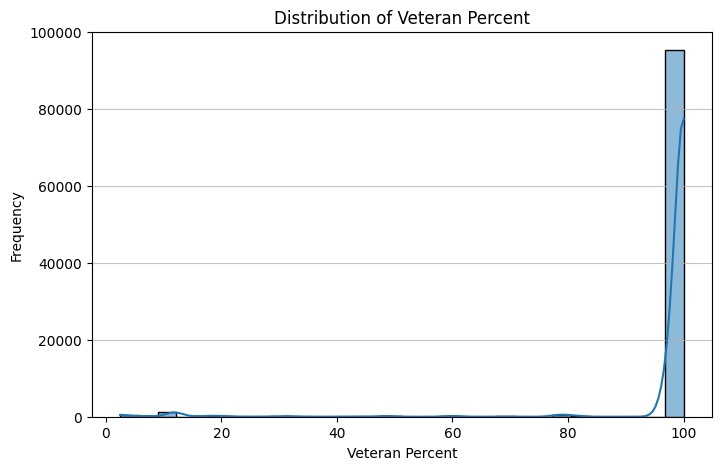

Histogram for 'Female Percent' saved to: /content/drive/MyDrive/Colab Notebooks/Data set/histograms/distribution_of_Female_Percent.png


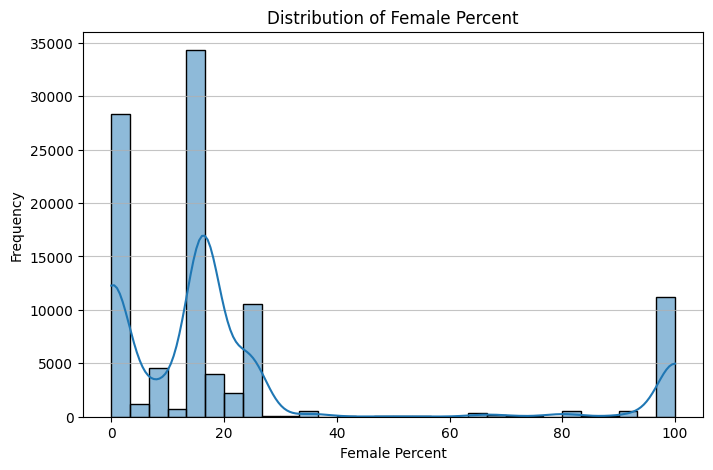

Histogram for 'Male Percent' saved to: /content/drive/MyDrive/Colab Notebooks/Data set/histograms/distribution_of_Male_Percent.png


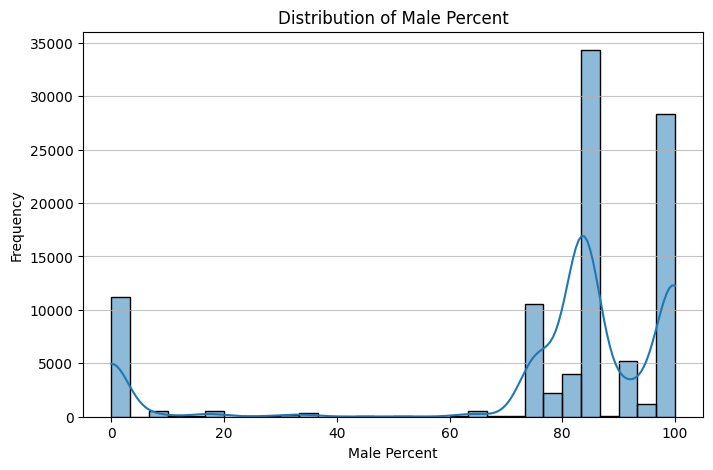

Histogram for 'baseline_severity' saved to: /content/drive/MyDrive/Colab Notebooks/Data set/histograms/distribution_of_baseline_severity.png


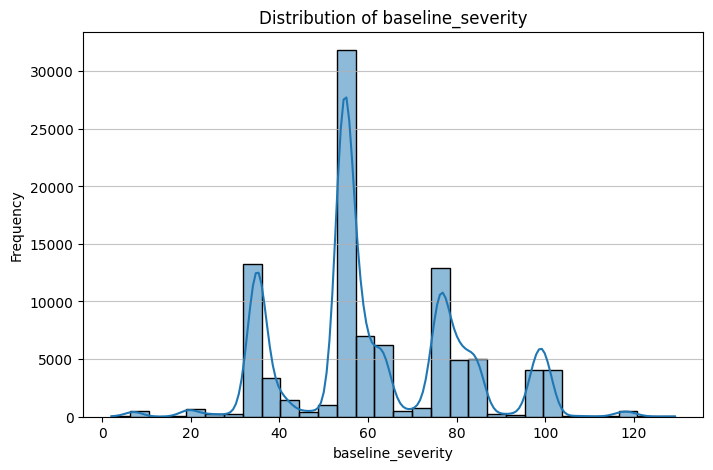

Histogram for 'baseline_z' saved to: /content/drive/MyDrive/Colab Notebooks/Data set/histograms/distribution_of_baseline_z.png


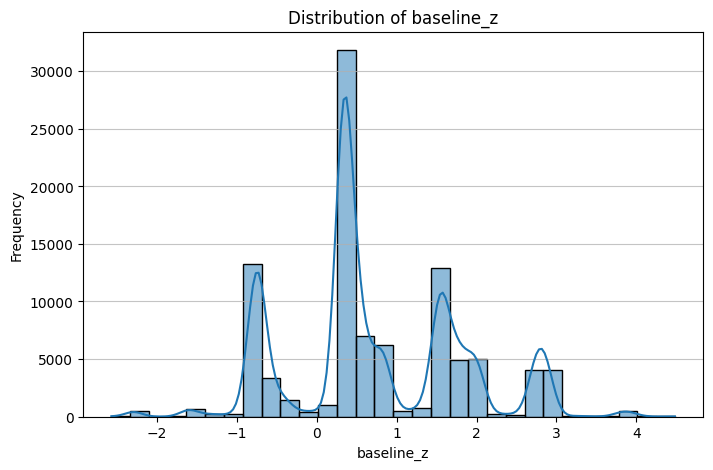

Histogram for 'treatment_duration' saved to: /content/drive/MyDrive/Colab Notebooks/Data set/histograms/distribution_of_treatment_duration.png


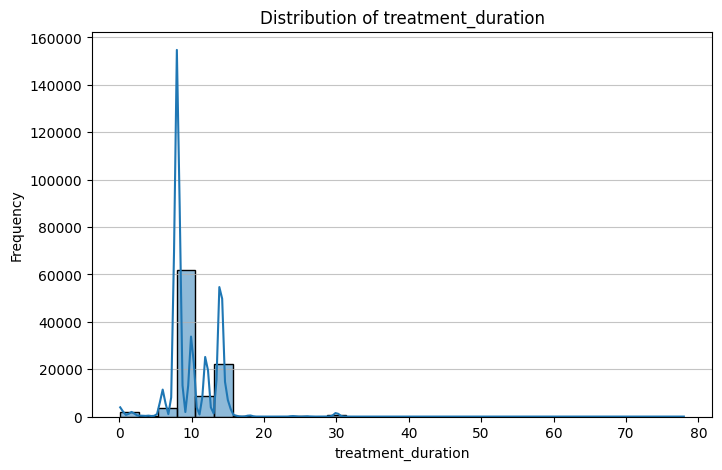

Histogram for 'Percent Achieved Diagnostic Change' saved to: /content/drive/MyDrive/Colab Notebooks/Data set/histograms/distribution_of_Percent_Achieved_Diagnostic_Change.png


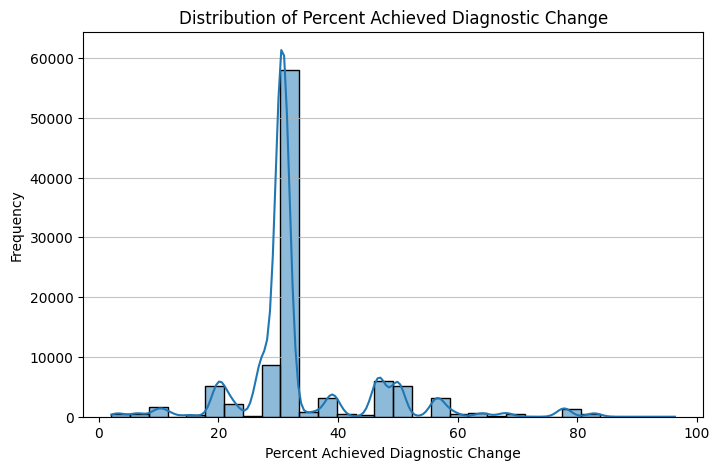

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure the output directory exists
output_image_dir = os.path.join(data_path, 'histograms')
os.makedirs(output_image_dir, exist_ok=True)

for col in continuous_vars:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col].dropna(), bins=30, kde=True, edgecolor='black') # Using seaborn for better aesthetics and KDE
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)

    # Save the figure
    image_filename = f"distribution_of_{col.replace(' ', '_').replace('%', 'percent')}.png"
    image_filepath = os.path.join(output_image_dir, image_filename)
    plt.savefig(image_filepath, bbox_inches='tight')
    print(f"Histogram for '{col}' saved to: {image_filepath}")

    plt.show()

In [ ]:
# ==========================
# DATASET SUITABILITY
# ==========================

print("Observations:", df.shape[0])
print("Variables:", df.shape[1])

print("\nOutcome Distribution:")
print(df['binary_outcome'].value_counts())

print("\nOutcome Percentage:")
print(
    round(
        df['binary_outcome'].value_counts(normalize=True)*100,
        2
    )
)

Observations: 99491
Variables: 203

Outcome Distribution:
binary_outcome
0.0    87642
1.0    11849
Name: count, dtype: int64

Outcome Percentage:
binary_outcome
0.0    88.09
1.0    11.91
Name: proportion, dtype: float64


### Calculate Skewness and Kurtosis

In [ ]:
from scipy.stats import skew, kurtosis

distribution_stats = pd.DataFrame({
    'Variable': continuous_vars,
    'Skewness': [round(skew(df[var].dropna()), 3) for var in continuous_vars],
    'Kurtosis': [round(kurtosis(df[var].dropna()), 3) for var in continuous_vars]
})
display(distribution_stats)

,Variable,Skewness,Kurtosis
0,Veteran Percent,-5.449,28.757
1,Female Percent,1.885,2.196
2,Male Percent,-1.883,2.187
3,baseline_severity,0.307,-0.194
4,baseline_z,0.307,-0.194
5,treatment_duration,1.396,10.683
6,Percent Achieved Diagnostic Change,1.472,3.766


Create Dissertation Table 4.2a

In [ ]:
table_4_2a = distribution_stats.copy()
display(table_4_2a)

,Variable,Skewness,Kurtosis
0,Veteran Percent,-5.449,28.757
1,Female Percent,1.885,2.196
2,Male Percent,-1.883,2.187
3,baseline_severity,0.307,-0.194
4,baseline_z,0.307,-0.194
5,treatment_duration,1.396,10.683
6,Percent Achieved Diagnostic Change,1.472,3.766


### Export Table to Excel

### Step 3: Export Table to Excel

In [ ]:
table_4_2a.to_excel(
    "Table_4_2a_Distribution_Assessment.xlsx",
    index=False
)

print("Table exported successfully.")

Table exported successfully.


### Outcome Frequency Table

## 4.2.3 Distribution of Treatment Success

This section assesses the distribution of the `binary_outcome` variable, which is crucial for understanding class imbalance in the dataset.

### Step 1: Outcome Frequency Table

In [ ]:
outcome_counts = (
    df['binary_outcome']
    .value_counts()
    .sort_index()
)

outcome_percentages = (
    df['binary_outcome']
    .value_counts(normalize=True)
    .sort_index() * 100
)

table_4_3 = pd.DataFrame({
    'Outcome': ['Failure (0)', 'Success (1)'],
    'Frequency': outcome_counts.values,
    'Percentage': outcome_percentages.round(2).values
})

display(table_4_3)

,Outcome,Frequency,Percentage
0,Failure (0),87642,88.09
1,Success (1),11849,11.91


### Generate Figure 4.1 (Outcome Distribution Bar Plot)

In [ ]:
table_4_3.to_excel(
    "Table_4_3_Outcome_Distribution.xlsx",
    index=False
)
print("Table 4.3 exported successfully to 'Table_4_3_Outcome_Distribution.xlsx'.")

Table 4.3 exported successfully to 'Table_4_3_Outcome_Distribution.xlsx'.


### Generate Figure 4.1

Figure 4.1 saved to 'Figure_4_1_Outcome_Distribution.png'.


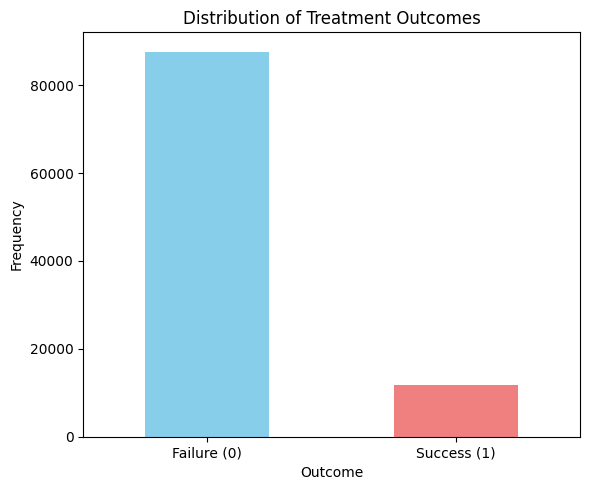

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

df['binary_outcome'].value_counts().sort_index().plot(
    kind='bar',
    color=['skyblue', 'lightcoral'] # Added colors for better visualization
)

plt.title('Distribution of Treatment Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Frequency')

plt.xticks(
    [0,1],
    ['Failure (0)', 'Success (1)'],
    rotation=0
)

plt.tight_layout()

plt.savefig(
    'Figure_4_1_Outcome_Distribution.png',
    dpi=300,
    bbox_inches='tight'
)

print("Figure 4.1 saved to 'Figure_4_1_Outcome_Distribution.png'.")
plt.show()

## 4.3 Logistic Regression Model Development

In [ ]:
for col in df.columns:
    print(col)

arm_id
Group
Study ID
Diagnostic Measure
Clinical Setting
Military Status
Veteran Percent
Female Percent
Male Percent
baseline_z
treatment_duration
baseline_severity
Percent Achieved Diagnostic Change
binary_outcome
Trauma Type_Combat-related
Trauma Type_MST
Trauma Type_Mixed
Trauma Type_Other
Delivery Method_In Person
Delivery Method_In person
Delivery Method_Mixed
Delivery Method_Phone
Delivery Method_Technology Alone
Delivery Method_Technology Assisted
Delivery Method_Technology alone
Delivery Method_Technology assisted
Delivery Method_Video
Delivery Method_Written
Standardized Treatment Name_Accelerated Resolution Therapy (ART)
Standardized Treatment Name_Acupuncture
Standardized Treatment Name_Adaptive Disclosure (AD)
Standardized Treatment Name_Amitriptyline
Standardized Treatment Name_Animal Assisted
Standardized Treatment Name_Aripiprazole augmentation
Standardized Treatment Name_Art therapy + Cognitive Processing Therapy (CPT)
Standardized Treatment Name_Assessment
Standardize

### One-Hot Encode Remaining Categorical Features

In [ ]:
df = pd.get_dummies(df, columns=['Diagnostic Measure', 'Clinical Setting', 'Military Status', 'Group'])

### Verify Columns After One-Hot Encoding

In [ ]:
print('Columns after one-hot encoding:')
print(df.columns.tolist())
print(f'New shape: {df.shape}')

Columns after one-hot encoding:
['arm_id', 'Study ID', 'Veteran Percent', 'Female Percent', 'Male Percent', 'baseline_z', 'treatment_duration', 'baseline_severity', 'Percent Achieved Diagnostic Change', 'binary_outcome', 'Trauma Type_Combat-related', 'Trauma Type_MST', 'Trauma Type_Mixed', 'Trauma Type_Other', 'Delivery Method_In Person', 'Delivery Method_In person', 'Delivery Method_Mixed', 'Delivery Method_Phone', 'Delivery Method_Technology Alone', 'Delivery Method_Technology Assisted', 'Delivery Method_Technology alone', 'Delivery Method_Technology assisted', 'Delivery Method_Video', 'Delivery Method_Written', 'Standardized Treatment Name_Accelerated Resolution Therapy (ART)', 'Standardized Treatment Name_Acupuncture', 'Standardized Treatment Name_Adaptive Disclosure (AD)', 'Standardized Treatment Name_Amitriptyline', 'Standardized Treatment Name_Animal Assisted', 'Standardized Treatment Name_Aripiprazole augmentation', 'Standardized Treatment Name_Art therapy + Cognitive Processin

### Define Features (X) and Target (y) for Logistic Regression

In [ ]:
y = df['binary_outcome']

X = df.drop(columns=[
    'arm_id',
    'Study ID',
    'binary_outcome',
    'Percent Achieved Diagnostic Change',
    'Male Percent',
    'baseline_severity'
])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget variable (y) value counts:")
print(y.value_counts())

X shape: (99491, 238)
y shape: (99491,)

Target variable (y) value counts:
binary_outcome
0.0    87642
1.0    11849
Name: count, dtype: int64


### Verify Data Types of Features

In [ ]:
print(X.dtypes.value_counts())

bool       234
float64      4
Name: count, dtype: int64


### Check for Missing Values in Features

In [ ]:
print("Missing values:", X.isnull().sum().sum())

Missing values: 0


### Verify Data Types and Missing Values (Redundant Check)

In [ ]:
print(X.dtypes.value_counts())
print("Missing values:", X.isnull().sum().sum())

bool       234
float64      4
Name: count, dtype: int64
Missing values: 0


### Summarize Predictor Categories

In [ ]:
predictor_summary = {
    "Veteran Percent": sum(col == "Veteran Percent" for col in X.columns),
    "Female Percent": sum(col == "Female Percent" for col in X.columns),
    "baseline_z": sum(col == "baseline_z" for col in X.columns),
    "treatment_duration": sum(col == "treatment_duration" for col in X.columns),

    "Trauma Type": sum(col.startswith("Trauma Type_") for col in X.columns),
    "Delivery Method": sum(col.startswith("Delivery Method_") for col in X.columns),
    "Treatment Name": sum(col.startswith("Standardized Treatment Name_") for col in X.columns),
    "Diagnostic Measure": sum(col.startswith("Diagnostic Measure_") for col in X.columns),
    "Clinical Setting": sum(col.startswith("Clinical Setting_") for col in X.columns),
    "Military Status": sum(col.startswith("Military Status_") for col in X.columns),
    "Group": sum(col.startswith("Group_") for col in X.columns)
}

for k, v in predictor_summary.items():
    print(f"{k}: {v}")

Veteran Percent: 1
Female Percent: 1
baseline_z: 1
treatment_duration: 1
Trauma Type: 4
Delivery Method: 10
Treatment Name: 175
Diagnostic Measure: 25
Clinical Setting: 14
Military Status: 2
Group: 4


### Split Data into Training and Testing Sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining outcomes:")
print(y_train.value_counts())

print("\nTesting outcomes:")
print(y_test.value_counts())

Training set shape: (79592, 238)
Testing set shape: (19899, 238)

Training outcomes:
binary_outcome
0.0    70113
1.0     9479
Name: count, dtype: int64

Testing outcomes:
binary_outcome
0.0    17529
1.0     2370
Name: count, dtype: int64


### Verify Stratification in Train/Test Split

In [ ]:
print("Full Dataset")
print(round(y.value_counts(normalize=True) * 100, 2))

print("\nTraining Dataset")
print(round(y_train.value_counts(normalize=True) * 100, 2))

print("\nTesting Dataset")
print(round(y_test.value_counts(normalize=True) * 100, 2))

Full Dataset
binary_outcome
0.0    88.09
1.0    11.91
Name: proportion, dtype: float64

Training Dataset
binary_outcome
0.0    88.09
1.0    11.91
Name: proportion, dtype: float64

Testing Dataset
binary_outcome
0.0    88.09
1.0    11.91
Name: proportion, dtype: float64


### Initialize Logistic Regression Model with Class Weights

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)

### Calculate Class Weights Manually (for verification)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

for cls, weight in zip(classes, weights):
    print(f"Class {int(cls)} weight: {weight:.4f}")

Class 0 weight: 0.5676
Class 1 weight: 4.1983


### Train Logistic Regression Model

In [ ]:
log_reg.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 4.3.1 Model Evaluation

In [ ]:
y_pred = log_reg.predict(X_test)

y_pred_proba = log_reg.predict_proba(X_test)[:,1]

### Calculate Evaluation Metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

accuracy = round(accuracy_score(y_test, y_pred),4)
precision = round(precision_score(y_test, y_pred),4)
recall = round(recall_score(y_test, y_pred),4)
f1 = round(f1_score(y_test, y_pred),4)
roc_auc = round(roc_auc_score(y_test, y_pred_proba),4)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

# Create a DataFrame for the metrics
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Value': [accuracy, precision, recall, f1, roc_auc]
})

# Export to Excel
metrics_df.to_excel("Table_4_5_Model_Performance_Metrics.xlsx", index=False)

print("\nModel performance metrics exported successfully to 'Table_4_5_Model_Performance_Metrics.xlsx'.")

Accuracy: 0.969
Precision: 0.7939
Recall: 0.9996
F1 Score: 0.8849
ROC-AUC: 0.995

Model performance metrics exported successfully to 'Table_4_5_Model_Performance_Metrics.xlsx'.


### Confusion Matrix

[[16914   615]
 [    1  2369]]


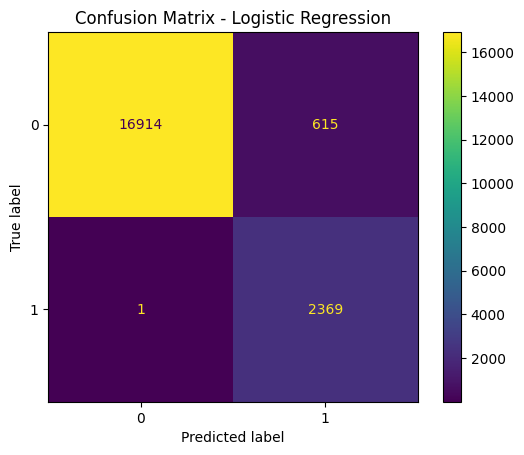

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### ROC Curve

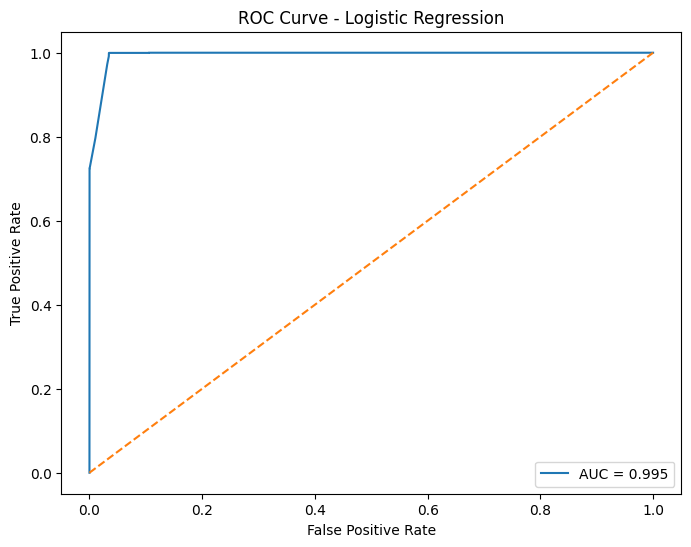

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_proba
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

### Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98     17529
         1.0       0.79      1.00      0.88      2370

    accuracy                           0.97     19899
   macro avg       0.90      0.98      0.93     19899
weighted avg       0.98      0.97      0.97     19899



## 4.3.2 Model Interpretation

In [ ]:
import pandas as pd
import numpy as np

coef_df = pd.DataFrame({
    'Predictor': X_train.columns,
    'Coefficient': log_reg.coef_[0]
})

coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

print("Top 20 Predictors by Coefficient (and Odds Ratio):")
display(coef_df.head(20))

Top 20 Predictors by Coefficient (and Odds Ratio):


,Predictor,Coefficient,Odds_Ratio
69,Standardized Treatment Name_Eye Movement Desen...,8.122919,3370.846808
100,Standardized Treatment Name_MDMA-assisted psyc...,7.931848,2784.568646
55,Standardized Treatment Name_Concurrent Treatme...,7.080783,1188.898885
219,Clinical Setting_Intensive outpatient,7.013049,1111.036367
19,Standardized Treatment Name_Acupuncture,6.717583,826.816266
189,Standardized Treatment Name_Written Exposure T...,6.255921,521.089203
10,Delivery Method_Mixed,5.567700,261.831309
173,Standardized Treatment Name_Transcendental med...,3.974616,53.229649
201,Diagnostic Measure_DSM,3.793504,44.411744
194,Diagnostic Measure_CAPS and DSM,3.229678,25.271525


### Top 20 Predictors by Coefficient and Odds Ratio

In [ ]:
print("15 Strongest Positive Predictors (highest coefficients):")
display(coef_df.sort_values(
    by='Coefficient',
    ascending=False
).head(15))

15 Strongest Positive Predictors (highest coefficients):


,Predictor,Coefficient,Odds_Ratio
69,Standardized Treatment Name_Eye Movement Desen...,8.122919,3370.846808
100,Standardized Treatment Name_MDMA-assisted psyc...,7.931848,2784.568646
55,Standardized Treatment Name_Concurrent Treatme...,7.080783,1188.898885
219,Clinical Setting_Intensive outpatient,7.013049,1111.036367
19,Standardized Treatment Name_Acupuncture,6.717583,826.816266
189,Standardized Treatment Name_Written Exposure T...,6.255921,521.089203
10,Delivery Method_Mixed,5.567700,261.831309
173,Standardized Treatment Name_Transcendental med...,3.974616,53.229649
201,Diagnostic Measure_DSM,3.793504,44.411744
194,Diagnostic Measure_CAPS and DSM,3.229678,25.271525


### 15 Strongest Positive Predictors

In [ ]:
print("15 Strongest Negative Predictors (lowest coefficients):")
display(coef_df.sort_values(
    by='Coefficient',
    ascending=True
).head(15))

15 Strongest Negative Predictors (lowest coefficients):


,Predictor,Coefficient,Odds_Ratio
215,Diagnostic Measure_SI-PTSD,-3.781878,0.022780
147,Standardized Treatment Name_Relapse Prevention,-3.318631,0.036202
196,Diagnostic Measure_CAPS and MINI,-3.030945,0.048270
106,Standardized Treatment Name_Mindfulness-based ...,-2.853236,0.057657
187,Standardized Treatment Name_Waitlist,-2.639268,0.071413
75,Standardized Treatment Name_High Delta-9-tetra...,-2.345067,0.095841
110,Standardized Treatment Name_Multi-modular moti...,-2.256825,0.104682
179,Standardized Treatment Name_Treatment as usual...,-2.250330,0.105364
220,Clinical Setting_Mixed,-2.228911,0.107646
141,Standardized Treatment Name_Psychotherapy,-2.160863,0.115226


### 15 Strongest Negative Predictors

In [ ]:
import statsmodels.api as sm

# 1. Define the list of corrected reduced predictors
# Exclude 'Trauma Type_MST' and 'Trauma Type_Other'

# Start with continuous variables
reduced_predictors_corrected = [
    'Veteran Percent',
    'Female Percent',
    'baseline_z',
    'treatment_duration'
]

# Add 'Trauma Type_' columns, excluding the problematic ones
trauma_type_cols_corrected = [
    col for col in X_train.columns if col.startswith('Trauma Type_')
    and col not in ['Trauma Type_MST', 'Trauma Type_Other']
]
reduced_predictors_corrected.extend(trauma_type_cols_corrected)

# 2. Create the new DataFrame X_train_reduced_corrected
X_train_reduced_corrected = X_train[reduced_predictors_corrected].copy()

# 3. Add a constant to X_train_reduced_corrected for statsmodels
X_train_reduced_sm_corrected = sm.add_constant(X_train_reduced_corrected)

print("Corrected reduced predictors defined:")
print(reduced_predictors_corrected)
print("Shape of X_train_reduced_sm_corrected:", X_train_reduced_sm_corrected.shape)
print("Columns in X_train_reduced_sm_corrected:", X_train_reduced_sm_corrected.columns.tolist())

Corrected reduced predictors defined:
['Veteran Percent', 'Female Percent', 'baseline_z', 'treatment_duration', 'Trauma Type_Combat-related', 'Trauma Type_Mixed']
Shape of X_train_reduced_sm_corrected: (79592, 7)
Columns in X_train_reduced_sm_corrected: ['const', 'Veteran Percent', 'Female Percent', 'baseline_z', 'treatment_duration', 'Trauma Type_Combat-related', 'Trauma Type_Mixed']


### Convert Boolean Columns to Integers for Statsmodels

In [ ]:
print('Original dtypes of X_train_reduced_sm_corrected:')
print(X_train_reduced_sm_corrected.dtypes)

# Convert boolean columns to integer type (0 or 1)
for col in X_train_reduced_sm_corrected.columns:
    if X_train_reduced_sm_corrected[col].dtype == 'bool':
        X_train_reduced_sm_corrected[col] = X_train_reduced_sm_corrected[col].astype(int)

print('\nCorrected dtypes of X_train_reduced_sm_corrected:')
print(X_train_reduced_sm_corrected.dtypes)

Original dtypes of X_train_reduced_sm_corrected:
const                         float64
Veteran Percent               float64
Female Percent                float64
baseline_z                    float64
treatment_duration            float64
Trauma Type_Combat-related       bool
Trauma Type_Mixed                bool
dtype: object

Corrected dtypes of X_train_reduced_sm_corrected:
const                         float64
Veteran Percent               float64
Female Percent                float64
baseline_z                    float64
treatment_duration            float64
Trauma Type_Combat-related      int64
Trauma Type_Mixed               int64
dtype: object


### Fit Reduced Logistic Regression Model using Statsmodels

In [ ]:
logit_model_reduced_corrected = sm.Logit(y_train, X_train_reduced_sm_corrected)
logit_model_reduced_corrected_result = logit_model_reduced_corrected.fit(maxiter=1000, disp=False)

print("Corrected reduced Logit model fitted successfully.")

Corrected reduced Logit model fitted successfully.


### Display Coefficients and Odds Ratios for Reduced Model

In [ ]:
import numpy as np

# Get the coefficients from the fitted model
coefficients = logit_model_reduced_corrected_result.params

# Calculate the odds ratios by exponentiating the coefficients
odds_ratios = np.exp(coefficients)

# Create a DataFrame to display coefficients and odds ratios
odds_ratios_df = pd.DataFrame({
    'Predictor': coefficients.index,
    'Coefficient': coefficients.values,
    'Odds_Ratio': odds_ratios.values
})

# Sort by Odds Ratio for better readability
odds_ratios_df = odds_ratios_df.sort_values(by='Odds_Ratio', ascending=False)

print("Coefficients and Odds Ratios from the corrected reduced Logit model:")
display(odds_ratios_df)

Coefficients and Odds Ratios from the corrected reduced Logit model:


,Predictor,Coefficient,Odds_Ratio
6,Trauma Type_Mixed,2.700018,14.879996
5,Trauma Type_Combat-related,1.857096,6.405112
1,Veteran Percent,0.018964,1.019145
4,treatment_duration,-0.011395,0.988669
2,Female Percent,-0.013871,0.986225
3,baseline_z,-1.761145,0.171848
0,const,-5.747352,0.003191


### Display Full Summary of Reduced Logit Model

In [ ]:
print(logit_model_reduced_corrected_result.summary())

                           Logit Regression Results                           
Dep. Variable:         binary_outcome   No. Observations:                79592
Model:                          Logit   Df Residuals:                    79585
Method:                           MLE   Df Model:                            6
Date:                Wed, 08 Jul 2026   Pseudo R-squ.:                  0.3064
Time:                        20:11:24   Log-Likelihood:                -20158.
converged:                       True   LL-Null:                       -29060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -5.7474      0.237    -24.283      0.000      -6.211      -5.283
Veteran Percent                0.0190      0.002     12.603      0.000       0.016 

### Create Dissertation Table 4.5

In [ ]:
import pandas as pd
import numpy as np

# Extract coefficients, p-values, and odds ratios
coefficients = logit_model_reduced_corrected_result.params
p_values = logit_model_reduced_corrected_result.pvalues

odds_ratios = np.exp(coefficients)

# Create the DataFrame for the table
table_data = pd.DataFrame({
    'Predictor': coefficients.index,
    'Coefficient': coefficients.values,
    'Odds Ratio': odds_ratios.values,
    'p-value': p_values.values
})

# Format p-values as '<0.001' or actual value
table_data['p-value'] = table_data['p-value'].apply(lambda x: '<0.001' if x < 0.001 else round(x, 3))

# Sort for better readability, similar to the example
table_data = table_data.sort_values(by='Coefficient', ascending=False).reset_index(drop=True)

# Display the table
print("Dissertation Table 4.5: Logistic Regression Coefficients, Odds Ratios, and P-values")
display(table_data)


Dissertation Table 4.5: Logistic Regression Coefficients, Odds Ratios, and P-values


,Predictor,Coefficient,Odds Ratio,p-value
0,Trauma Type_Mixed,2.700018,14.879996,<0.001
1,Trauma Type_Combat-related,1.857096,6.405112,<0.001
2,Veteran Percent,0.018964,1.019145,<0.001
3,treatment_duration,-0.011395,0.988669,0.023
4,Female Percent,-0.013871,0.986225,<0.001
5,baseline_z,-1.761145,0.171848,<0.001
6,const,-5.747352,0.003191,<0.001


### Export Dissertation Table 4.5

In [ ]:
table_data.to_excel(
    "Table_4_5_Logistic_Regression_Results.xlsx",
    index=False
)

print("Dissertation Table 4.5 exported successfully to 'Table_4_5_Logistic_Regression_Results.xlsx'.")


Dissertation Table 4.5 exported successfully to 'Table_4_5_Logistic_Regression_Results.xlsx'.


### Visualize Odds Ratios of Reduced Model Predictors

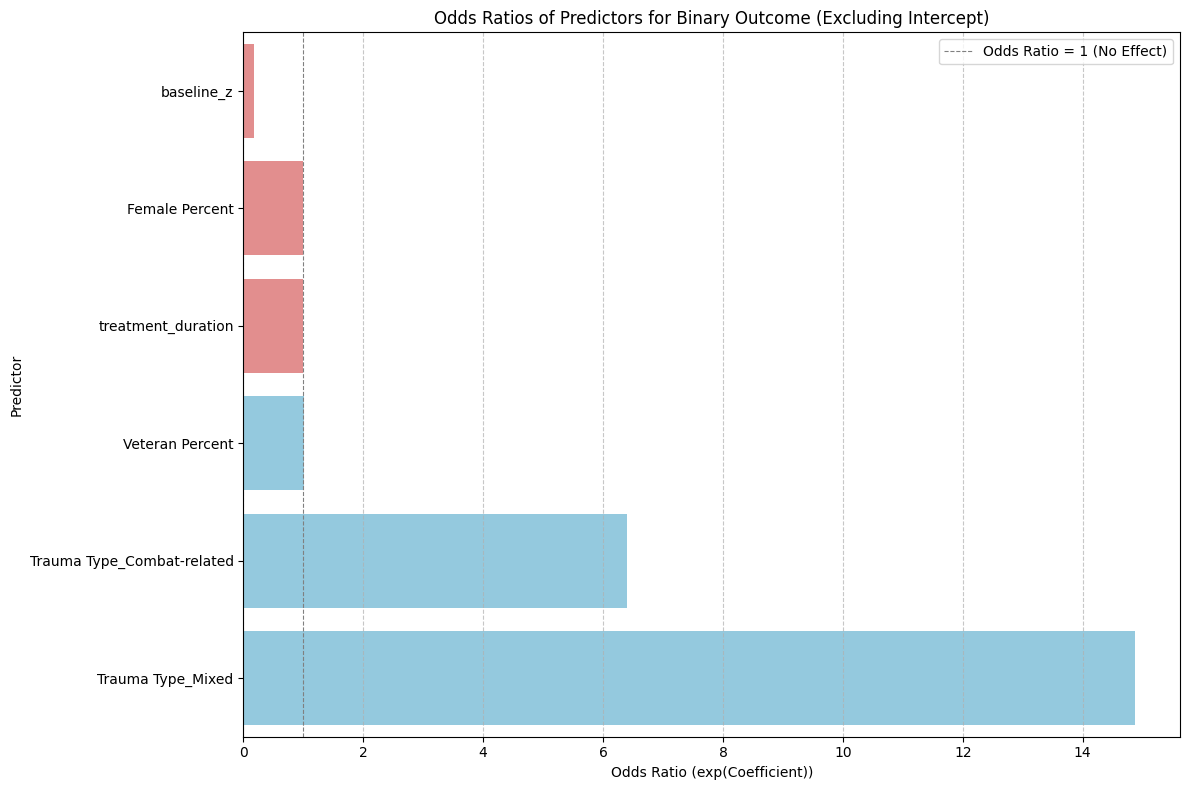

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude the 'const' variable for plotting as it's an intercept term
odds_ratios_to_plot = odds_ratios_df[odds_ratios_df['Predictor'] != 'const'].copy()

# Sort by Odds Ratio for plotting
odds_ratios_to_plot = odds_ratios_to_plot.sort_values(by='Odds_Ratio', ascending=True)

# Create a color map for visualization: blue for odds ratio > 1 (increased odds), red for < 1 (decreased odds)
odds_ratios_to_plot['color'] = odds_ratios_to_plot['Odds_Ratio'].apply(lambda x: 'skyblue' if x > 1 else 'lightcoral')

# Visualize the odds ratios
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Odds_Ratio',
    y='Predictor',
    hue='Predictor', # Assign 'Predictor' to hue for coloring
    data=odds_ratios_to_plot,
    palette=odds_ratios_to_plot['color'].tolist(),
    legend=False # Set legend to False to avoid duplicate legend
)
plt.title('Odds Ratios of Predictors for Binary Outcome (Excluding Intercept)')
plt.xlabel('Odds Ratio (exp(Coefficient))')
plt.ylabel('Predictor')
plt.axvline(x=1, color='gray', linestyle='--', linewidth=0.8, label='Odds Ratio = 1 (No Effect)')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 4.4 Calibration Analysis

Figure 4.4 Calibration Curve saved to 'Figure_4_4_Calibration_Curve.png'.


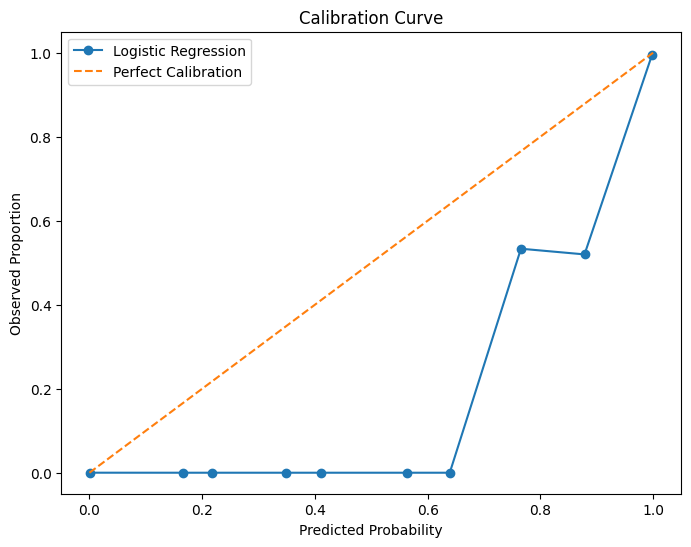

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    y_pred_proba,
    n_bins=10
)

plt.figure(figsize=(8,6))

plt.plot(
    prob_pred,
    prob_true,
    marker='o',
    label='Logistic Regression'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Perfect Calibration'
)

plt.xlabel('Predicted Probability')
plt.ylabel('Observed Proportion')

plt.title('Calibration Curve')

plt.legend()

plt.savefig(
    'Figure_4_4_Calibration_Curve.png',
    dpi=300,
    bbox_inches='tight'
)

print("Figure 4.4 Calibration Curve saved to 'Figure_4_4_Calibration_Curve.png'.")

plt.show()

### Calculate Brier Score

In [ ]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(
    y_test,
    y_pred_proba
)

print("Brier Score:", round(brier,4))

Brier Score: 0.0244


### Calculate Calibration Intercept and Slope

In [ ]:
import numpy as np
import statsmodels.api as sm

# Convert predicted probabilities to log-odds (logits)
logit_pred = np.log(
    y_pred_proba / (1 - y_pred_proba)
)

# Fit a logistic regression model with the true outcomes and predicted log-odds
calibration_model = sm.Logit(
    y_test,
    sm.add_constant(logit_pred) # Add a constant for the intercept
).fit(disp=False) # disp=False suppresses iteration details

print(calibration_model.summary())

# Extract the intercept and slope
intercept = calibration_model.params[0]
slope = calibration_model.params[1]

print("\nCalibration Intercept:", round(intercept, 4))
print("Calibration Slope:", round(slope, 4))

                           Logit Regression Results                           
Dep. Variable:         binary_outcome   No. Observations:                19899
Model:                          Logit   Df Residuals:                    19897
Method:                           MLE   Df Model:                            1
Date:                Wed, 08 Jul 2026   Pseudo R-squ.:                  0.8758
Time:                        20:11:26   Log-Likelihood:                -902.64
converged:                       True   LL-Null:                       -7265.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.5873      0.230    -11.229      0.000      -3.039      -2.136
x1             1.3520      0.112     12.088      0.000       1.133       1.571

Possibly complete quasi-separation: A fraction 0.82

/tmp/ipykernel_4000/2602956573.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = calibration_model.params[0]
/tmp/ipykernel_4000/2602956573.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = calibration_model.params[1]


### Verify Columns for Calibration Analysis (Redundant Check)

In [ ]:
print('Percent Achieved Diagnostic Change' in X.columns)
print('binary_outcome' in X.columns)

False
False


### Create Dissertation Table 4.6 (Calibration Measures)

In [ ]:
table_4_6 = pd.DataFrame({
    'Measure': [
        'Calibration Slope',
        'Calibration Intercept',
        'Brier Score'
    ],
    'Value': [
        round(slope, 4),
        round(intercept, 4),
        round(brier, 4)
    ]
})
display(table_4_6)

,Measure,Value
0,Calibration Slope,1.3520
1,Calibration Intercept,-2.5873
2,Brier Score,0.0244


### Export Dissertation Table 4.6

In [ ]:
table_4_6.to_excel(
    "Table_4_6_Calibration_Measures.xlsx",
    index=False
)
print("Table 4.6 exported successfully to 'Table_4_6_Calibration_Measures.xlsx'.")

Table 4.6 exported successfully to 'Table_4_6_Calibration_Measures.xlsx'.


### Identify Columns Containing 'score', 'change', 'difference', 'effect'

In [ ]:
for col in df.columns:
    if 'score' in col.lower() or 'change' in col.lower() or 'difference' in col.lower() or 'effect' in col.lower():
        print(col)

Percent Achieved Diagnostic Change
Standardized Treatment Name_Creating Change


### Define Features (X_linear) and Target (y_linear) for Linear Regression

## 4.5 Linear Regression Model Development

In [ ]:
X_linear = X.copy()
y_linear = df['Percent Achieved Diagnostic Change']

print("X_linear shape:", X_linear.shape)
print("y_linear shape:", y_linear.shape)

X_linear shape: (99491, 238)
y_linear shape: (99491,)


### Split Data for Linear Regression

In [ ]:
from sklearn.model_selection import train_test_split

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_linear,
    y_linear,
    test_size=0.20,
    random_state=42
)

print("Training set shape:", X_train_lr.shape)
print("Testing set shape:", X_test_lr.shape)

Training set shape: (79592, 238)
Testing set shape: (19899, 238)


### Train Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(
    X_train_lr,
    y_train_lr
)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Make Predictions with Linear Regression Model

In [ ]:
y_pred_lr = lin_reg.predict(X_test_lr)

### Evaluate Linear Regression Model Performance

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

r2 = r2_score(y_test_lr, y_pred_lr)

mae = mean_absolute_error(
    y_test_lr,
    y_pred_lr
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_lr,
        y_pred_lr
    )
)

print("R²:", round(r2,4))
print("MAE:", round(mae,4))
print("RMSE:", round(rmse,4))

# Create a DataFrame for the metrics
table_4_7 = pd.DataFrame({
    'Metric': ['R²', 'MAE', 'RMSE'],
    'Value': [round(r2, 4), round(mae, 4), round(rmse, 4)]
})

# Display and export to Excel
display(table_4_7)

table_4_7.to_excel(
    "Table_4_7_Linear_Regression_Performance.xlsx",
    index=False
)

print("Table 4.7 exported successfully to 'Table_4_7_Linear_Regression_Performance.xlsx'.")

R²: 0.9136
MAE: 1.8192
RMSE: 3.3975


,Metric,Value
0,R²,0.9136
1,MAE,1.8192
2,RMSE,3.3975


Table 4.7 exported successfully to 'Table_4_7_Linear_Regression_Performance.xlsx'.


### Residual Plot

Figure 4.5 Residual Plot saved to 'Figure_4_5_Residual_Plot.png'.


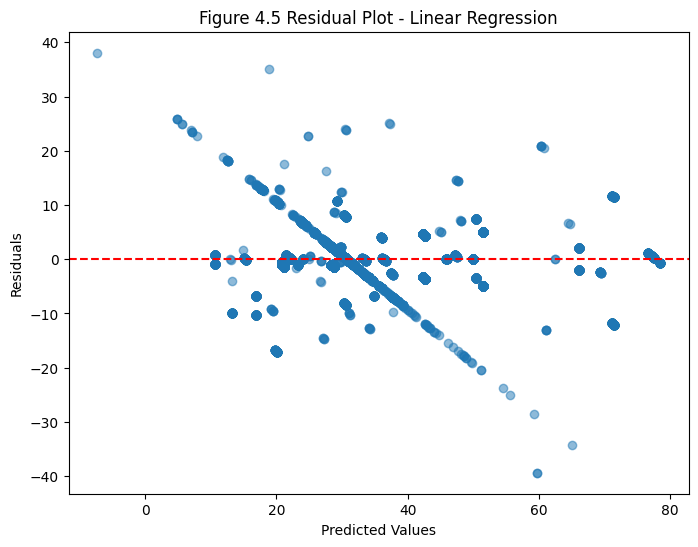

In [ ]:
import matplotlib.pyplot as plt

residuals = y_test_lr - y_pred_lr

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_lr,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle='--',
    color='red'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Figure 4.5 Residual Plot - Linear Regression")

plt.savefig(
    'Figure_4_5_Residual_Plot.png',
    dpi=300,
    bbox_inches='tight'
)

print("Figure 4.5 Residual Plot saved to 'Figure_4_5_Residual_Plot.png'.")
plt.show()

### Residual Distribution Histogram

Figure 4.6 Residual Distribution saved to 'Figure_4_6_Residual_Distribution.png'.


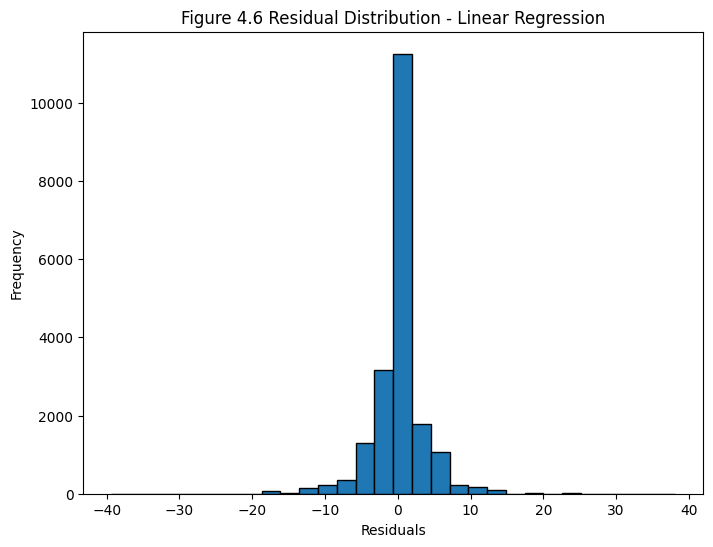

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.hist(
    residuals,
    bins=30,
    edgecolor='black'
)

plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.title("Figure 4.6 Residual Distribution - Linear Regression")

plt.savefig(
    'Figure_4_6_Residual_Distribution.png',
    dpi=300,
    bbox_inches='tight'
)

print("Figure 4.6 Residual Distribution saved to 'Figure_4_6_Residual_Distribution.png'.")
plt.show()

### Q-Q Plot of Residuals

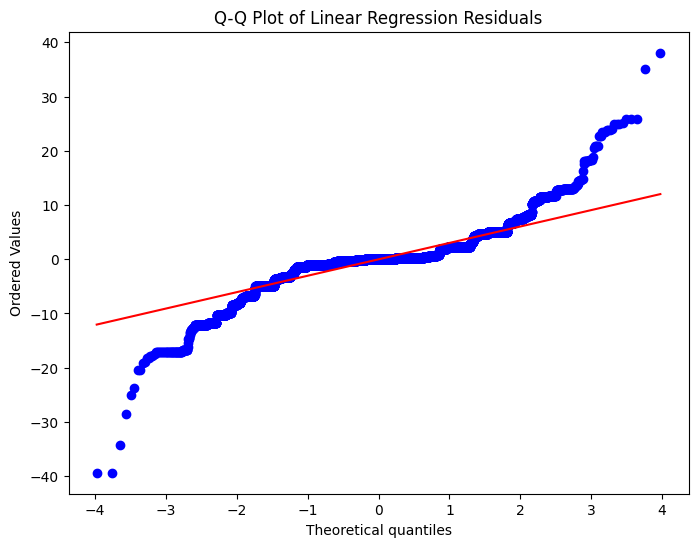

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.figure(figsize=(8,6))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Linear Regression Residuals")

plt.show()

### Display Top Linear Regression Coefficients

In [ ]:
coef_df_lr = pd.DataFrame({
    'Predictor': X_linear.columns,
    'Coefficient': lin_reg.coef_
})

coef_df_lr = coef_df_lr.sort_values(
    by='Coefficient',
    ascending=False
)

print("Linear Regression Coefficients (Top 20):")
display(coef_df_lr.head(20))

Linear Regression Coefficients (Top 20):


,Predictor,Coefficient
64,Standardized Treatment Name_Emotional Freedom ...,61.711063
178,Standardized Treatment Name_Treatment as usual,41.089124
69,Standardized Treatment Name_Eye Movement Desen...,35.648566
15,Delivery Method_Technology assisted,27.506880
12,Delivery Method_Technology Alone,26.568466
9,Delivery Method_In person,26.023372
55,Standardized Treatment Name_Concurrent Treatme...,25.751846
14,Delivery Method_Technology alone,24.209093
120,Standardized Treatment Name_Paroxetine + placebo,23.813259
10,Delivery Method_Mixed,22.106606


### Prepare Reduced Features for Linear Regression (OLS)

In [ ]:
linear_vars = [
    'Veteran Percent',
    'Female Percent',
    'baseline_z',
    'treatment_duration',
    'Trauma Type_Combat-related',
    'Trauma Type_Mixed'
]

X_linear_reduced = df[linear_vars]

y_linear = df['Percent Achieved Diagnostic Change']

print("X_linear_reduced shape:", X_linear_reduced.shape)
print("y_linear shape:", y_linear.shape)

X_linear_reduced shape: (99491, 6)
y_linear shape: (99491,)


### Fit Reduced Linear Regression Model using Statsmodels (OLS)

In [ ]:
import statsmodels.api as sm

# Create a copy to avoid SettingWithCopyWarning
X_linear_reduced_copy = X_linear_reduced.copy()

# Ensure boolean columns are converted to int for statsmodels
for col in X_linear_reduced_copy.columns:
    if X_linear_reduced_copy[col].dtype == 'bool':
        X_linear_reduced_copy.loc[:, col] = X_linear_reduced_copy[col].astype(int)

X_linear_reduced_sm = sm.add_constant(X_linear_reduced_copy)

ols_model = sm.OLS(
    y_linear,
    X_linear_reduced_sm
).fit()

print(ols_model.summary())

                                    OLS Regression Results                                    
Dep. Variable:     Percent Achieved Diagnostic Change   R-squared:                       0.084
Model:                                            OLS   Adj. R-squared:                  0.084
Method:                                 Least Squares   F-statistic:                     1517.
Date:                                Wed, 08 Jul 2026   Prob (F-statistic):               0.00
Time:                                        20:11:30   Log-Likelihood:            -3.8114e+05
No. Observations:                               99491   AIC:                         7.623e+05
Df Residuals:                                   99484   BIC:                         7.624e+05
Df Model:                                           6                                         
Covariance Type:                            nonrobust                                         
                                 coef    std err  

/tmp/ipykernel_4000/4041272147.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X_linear_reduced_copy.loc[:, col] = X_linear_reduced_copy[col].astype(int)
/tmp/ipykernel_4000/4041272147.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 1 1 1]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X_linear_reduced_copy.loc[:, col] = X_linear_reduced_copy[col].astype(int)


### Display Coefficients, Standard Errors, and P-values for Reduced OLS Model

In [ ]:
results_table = pd.DataFrame({
    'Predictor': ols_model.params.index,
    'Coefficient': ols_model.params.values,
    'Standard Error': ols_model.bse.values,
    'p-value': ols_model.pvalues.values
})

# Format p-values as '<0.001' or actual value
results_table['p-value'] = results_table['p-value'].apply(lambda x: '<0.001' if x < 0.001 else round(x, 3))

display(results_table)

,Predictor,Coefficient,Standard Error,p-value
0,const,28.303131,0.306060,<0.001
1,Veteran Percent,0.026190,0.002555,<0.001
2,Female Percent,-0.010904,0.001328,<0.001
3,baseline_z,-3.089580,0.036078,<0.001
4,treatment_duration,-0.101864,0.013126,<0.001
5,Trauma Type_Combat-related,7.877399,0.209954,<0.001
6,Trauma Type_Mixed,6.072760,0.188928,<0.001


### Export Dissertation Table 4.8

In [ ]:
results_table.to_excel(
    "Table_4_8_Linear_Regression_Coefficients.xlsx",
    index=False
)

print("Export complete.")

Export complete.


### Calculate Variance Inflation Factor (VIF) for Reduced Model

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each predictor in X_linear_reduced_sm
vif_data = pd.DataFrame()
vif_data['Predictor'] = X_linear_reduced_sm.columns
vif_data['VIF'] = [variance_inflation_factor(X_linear_reduced_sm.values, i) for i in range(X_linear_reduced_sm.shape[1])]

# Sort the DataFrame by VIF values in descending order for easier interpretation
vif_data = vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True)

print("Variance Inflation Factor (VIF) for Predictors in Reduced Linear Regression Model:")
display(vif_data)

Variance Inflation Factor (VIF) for Predictors in Reduced Linear Regression Model:


,Predictor,VIF
0,const,74.884843
1,Trauma Type_Combat-related,6.940412
2,Trauma Type_Mixed,6.068183
3,treatment_duration,1.546106
4,Female Percent,1.278651
5,baseline_z,1.230551
6,Veteran Percent,1.117166


### Export Dissertation Table 4.9 (VIF Results)

In [ ]:
vif_data.to_excel(
    "Table_4_9_VIF_Results.xlsx",
    index=False
)

print("Variance Inflation Factor (VIF) results exported successfully to 'Table_4_9_VIF_Results.xlsx'.")

Variance Inflation Factor (VIF) results exported successfully to 'Table_4_9_VIF_Results.xlsx'.


## 4.6 Decision Curve Analysis (DCA)

In [ ]:
import numpy as np
import pandas as pd

thresholds = np.arange(0.01, 0.99, 0.01)

net_benefits = []

N = len(y_test)

for pt in thresholds:

    predictions = (y_pred_proba >= pt).astype(int)

    TP = ((predictions == 1) & (y_test == 1)).sum()
    FP = ((predictions == 1) & (y_test == 0)).sum()

    # Calculate Net Benefit (NB)
    # The formula is: NB = (TP / N) - (FP / N) * (pt / (1 - pt))
    # Where pt is the threshold probability (or probability of treatment)
    # and pt / (1 - pt) is the odds of harm (relative weight of false positives)
    nb = (TP / N) - (FP / N) * (pt / (1 - pt))

    net_benefits.append(nb)

dca_results = pd.DataFrame({
    'Threshold Probability': thresholds,
    'Net Benefit': net_benefits
})

print("Net Benefit values for the Prediction Model calculated.")
display(dca_results.head())

Net Benefit values for the Prediction Model calculated.


,Threshold Probability,Net Benefit
0,0.01,0.118500
1,0.02,0.118270
2,0.03,0.117898
3,0.04,0.117529
4,0.05,0.117163


### Calculate Net Benefit for Prediction Model

In [ ]:
prevalence = y_test.mean()

treat_all_nb = []

for pt in thresholds:
    # Net benefit for treating all individuals
    # NB_all = prevalence - (1 - prevalence) * (pt / (1 - pt))
    nb_all = prevalence - (1 - prevalence) * (pt / (1 - pt))
    treat_all_nb.append(nb_all)

print("Net Benefit values for 'Treat All' strategy calculated.")

Net Benefit values for 'Treat All' strategy calculated.


### Calculate Net Benefit for 'Treat All' Strategy

In [ ]:
# The net benefit for treating no individuals is always zero
treat_none_nb = np.zeros(len(thresholds))

print("Net Benefit values for 'Treat None' strategy defined (all zeros).")

Net Benefit values for 'Treat None' strategy defined (all zeros).


### Define Net Benefit for 'Treat None' Strategy

Figure 4.7 Decision Curve Analysis Plot (Enhanced) saved to 'Figure_4_7_Decision_Curve_Analysis_Enhanced.png'.


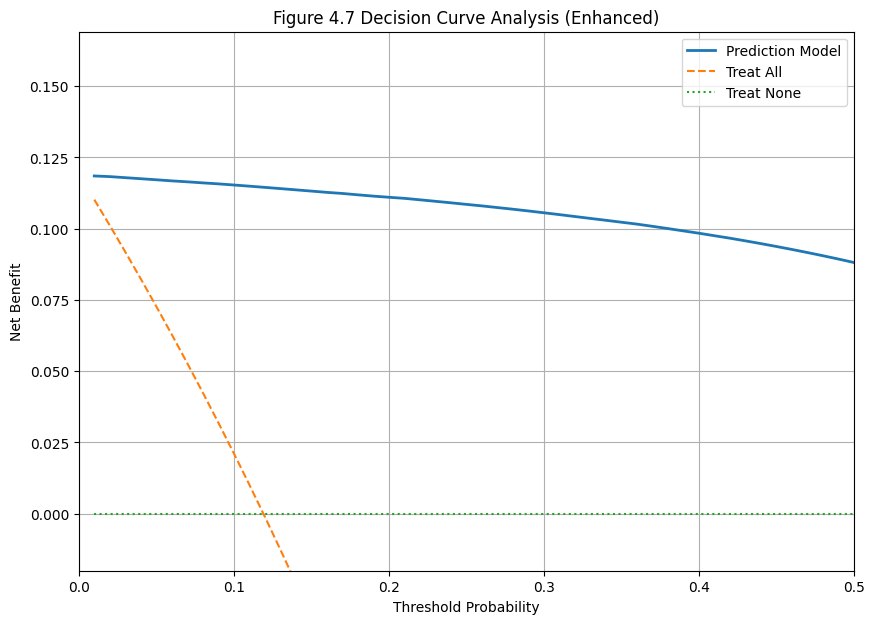

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

plt.plot(
    thresholds,
    net_benefits,
    label='Prediction Model',
    linewidth=2
)

plt.plot(
    thresholds,
    treat_all_nb,
    linestyle='--',
    label='Treat All'
)

plt.plot(
    thresholds,
    treat_none_nb,
    linestyle=':',
    label='Treat None'
)

plt.xlabel('Threshold Probability')

plt.ylabel('Net Benefit')

plt.title('Figure 4.7 Decision Curve Analysis (Enhanced)')

plt.legend()

plt.grid(True)

# --- FIX: Set clinically relevant axis limits ---
plt.xlim(0.0, 0.5) # Limit X-axis to 0% to 50% risk threshold
plt.ylim(-0.02, prevalence + 0.05) # Zoom Y-axis around the prevalence rate
# -------------------------------------------------

plt.savefig(
    'Figure_4_7_Decision_Curve_Analysis_Enhanced.png',
    dpi=300,
    bbox_inches='tight'
)

print("Figure 4.7 Decision Curve Analysis Plot (Enhanced) saved to 'Figure_4_7_Decision_Curve_Analysis_Enhanced.png'.")
plt.show()

### Create Dissertation Table 4.10 (DCA Results for Selected Thresholds)

In [ ]:
selected_thresholds = [0.10, 0.20, 0.30, 0.40, 0.50]

table_410 = dca_results[
    dca_results['Threshold Probability'].round(2).isin(selected_thresholds)
].copy()

print("Table 4.10 created for selected thresholds:")
display(table_410)

Table 4.10 created for selected thresholds:


,Threshold Probability,Net Benefit
9,0.1,0.115327
19,0.2,0.111023
29,0.3,0.105590
39,0.4,0.098414
49,0.5,0.088145


### Export Dissertation Table 4.10

In [ ]:
table_410.to_excel(
    "Table_4_10_DCA_Results.xlsx",
    index=False
)

print("Table 4.10 exported successfully to 'Table_4_10_DCA_Results.xlsx'.")

Table 4.10 exported successfully to 'Table_4_10_DCA_Results.xlsx'.
